# **Code Breaking with Statistical Physics**: Group 9
### **Authors**:
* Eleanor Hasler  
* Celine Hwang  
* Sadika Khan  
* Seyoung Lee  
* Tom Ryan

### **Project Overview**
This project explores the intersection of **statistical physics** and **cryptography**, demonstrating how thermodynamic concepts can be applied to break complex encryption codes. We begin with fundamental techniques like frequency analysis before implementing the **Metropolis algorithm**, a Monte Carlo method.

By treating a decrypted message's "plausibility" as an energy state, we effectively turn code-breaking into an energy minimisation problem. This allows us to navigate the vast search space of $27!$ keys to locate the global minimum (the plaintext) without brute force.

The project evolves from simple mono-alphabetic substitution ciphers to handle more sophisticated challenges, incorporating **trigram modelling**, **automated language detection**, and **hybrid dictionary scoring**. Finally, we demonstrate the algorithm's versatility by adapting the cipher key mutation logic to break **columnar transposition** and **Vigenère** ciphers.

## **Contents**

[Setup and Initialisation](#Setup-and-Initialisation)

---

[Core 1: A program to solve a Caesar cipher](#Core-1:-A-program-to-solve-a-Caesar-cipher)

[Core 2: A program to import, store, and assign a large sample of English text (Moby Dick)](#Core-2:-A-program-to-import,-store,-and-assign-a-large-sample-of-English-text-(Moby-Dick))

[Core 3: Frequency analysis to create a cipher key](#Core-3:-Frequency-analysis-to-create-a-cipher-key)

[Core 4: Manual key character swapping functionality](#Core-4:-Manual-key-character-swapping-functionality)

[Core 5: Bigram analysis and plausibility scoring](#Core-5:-Bigram-analysis-and-plausibility-scoring)

[Core 6: Metropolis algorithm for automated decryption](#Core-6:-Metropolis-algorithm-for-automated-decryption)

---

[Extension 7: Methodical Improvements](#Extension-7:-Methodical-Improvements)

[Extension 9: Parameter Optimisation for the Metropolis Algorithm](#Extension-9:-Parameter-Optimisation-for-the-Metropolis-Algorithm)

[Extension 10: Adaptation to Other Ciphers](#Extension-10:-Adaptation-to-Other-Ciphers)

---

[Full List of Deciphered Codes](#Full-List-of-Deciphered-Codes)

[Project Conclusion](#Project-Conclusion)

[Bibliography](#Bibliography)

## **Setup and Initialisation**
### Library Imports
The following libraries are essential for the functions in this notebook:
* `requests`: Used to download the reference text (Moby Dick) from Project Gutenberg.
* `os`: Handles file paths and directory creation, ensuring the code runs on Windows, Mac, or Linux.
* `re`: Provides regular expression support for efficient text cleaning.
* `operator`: Enables efficient sorting of frequency dictionaries.
* `math`: Used for logarithmic calculations to prevent arithmetic underflow in the scoring function.
* `random`: Used for the stochastic processes (random sampling) in the Metropolis algorithm.
* `unicodedata`: Used to clean accented characters in foreign source text, standardising them.
* `matplotlib.pyplot`: Used to visualise the solution space or results where necessary.
* `numpy`: Used for the vector and matrix-based mathematics when deciphering Transposition and Vigenère ciphers.

In [1]:
import requests
import os
import re
import operator
import math
import random
import copy
import unicodedata
import matplotlib.pyplot as plt
import numpy as np

### Alphabet Definition
This is the **27-character alphabet** used for all encryption and decryption operations. It consists of the 26 uppercase letters (A-Z) and the **space character**. 

In [2]:
alphabet = " ABCDEFGHIJKLMNOPQRSTUVWXYZ"
print(f'Alphabet successfully defined: "{alphabet}". It has length {len(alphabet)}.')

Alphabet successfully defined: " ABCDEFGHIJKLMNOPQRSTUVWXYZ". It has length 27.


### Coded Message Repository
A dictionary `codedMessages` is used to store the provided ciphertexts. This allows for easy selection of different messages (using integer keys 1-12) for analysis without cluttering the main code cells.

In [3]:
# Repository for all ciphertext inputs to ensure main code logic remains clean.
codedMessages = {
    1: "GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ",
    2: "RECFV KUWE VJCRWQFCRCFICYWEZRWKLVJWQF SCRRZ ALVWJLAACFWNATZVW NFWIZRZT FWELYWVCSTWNRWLVTE NBEWZTWHLRWCLRMWS FWJCWHE WUACHWEZJWR WHCVVWT WRCCWTELTWECWHLRWQF S NAYVMWCPKZTCYWTECWJ JCATWTELTWEZVT AWKNGZTTWRWGF LYWGLKUWELYWYZRLQQCLFCYWTEF NBEWTECWY FWJMWK JFLYCWFNRECYWT WTECWTLGVCWVLZYW NTWLVVWTECWRVZQRW SWQLQCFWK ATLZAZABWYLAKZABWJCAWZAWSF ATW SWEZJWLAYWTEFCHWEZJRCVSWZAT WLAWZATFZKLTCWLAYWCVLG FLTCWKLVKNVLTZ AWS FWTH WE NFRWZWHLTKECYWEZJWLRWECWK ICFCYWRECCTWLSTCFWRECCTW SWQLQCFWHZTEWSZBNFCRWLAYWVCTTCFRWR WK JQVCTCVMWLGR FGCYWZAWEZRWTLRUWTELTWECWELYWCIZYCATVMWS FB TTCAWJMWQFCRCAKCWR JCTZJCRWECWHLRWJLUZABWQF BFCRRWLAYWHEZRTVCYWLAYWRLABWLTWEZRWH FUWR JCTZJCRWECWHLRWQNDDVCYWLAYWH NVYWRZTWS FWV ABWRQCVVRWHZTEWLWSNFF HCYWGF HWLAYWLWILKLATWCMCWSZALVVMWECWRQFLABWSF JWEZRWKELZFWHZTEWLWKFMW SWRLTZRSLKTZ AWLAYWHLVUCYWNQWLAYWY HAWTECWF JWFNGGZABWEZRWELAYRWT BCTECFWTECAWECWHF TCWLWV ABWTCVCBFLJWNQ AWLWKLGVCWS FJWZSWJMWLARHCFWT WTEZRWZRWLRWZWE QCWM NWHZVVWELICWLWICFMWQFCTTMWKLRCWT WLYYWT WM NFWK VVCKTZ AWHLTR AWRLZYWECWZWCPQCKTWTELTWHCWRELVVWGCWLGVCWT WB WY HAWT WA FS VUWT J FF HWLAYWT WTLUCW NFWSFZCAYWR JCWICFMWYCSZAZTCWACHRWLRWT WTECWRCKFCTW SWEZRWLAA MLAKCWZWK ASCRRWTELTWZWHLRWSZVVCYWHZTEWKNFZ RZTMWGNTWZWHLRWLHLFCWTELTWE VJCRWVZUCYWT WJLUCWEZRWYZRKV RNFCRWLTWEZRW HAWTZJCWLAYWZAWEZRW HAWHLMWR WZWHLZTCYWNATZVWZTWRE NVYWRNZTWEZJWT WTLUCWJCWZAT WEZRWK ASZYCAKCWGNTWTECFCWHLRWLWYCVLMWZAWTELTWLARHCFZABWTCVCBFLJWLAYWTH WYLMRW SWZJQLTZCAKCWS VV HCYWYNFZABWHEZKEWE VJCRWQFZKUCYWNQWEZRWCLFRWLTWCICFMWFZABW SWTECWGCVVW AWTECWCICAZABW SWTECWRCK AYWTECFCWKLJCWLWVCTTCFWSF JWEZVT AWKNGZTTWLVVWHLRWXNZCTWHZTEWEZJWRLICWTELTWLWV ABWZARKFZQTZ AWELYWLQQCLFCYWTELTWJ FAZABWNQ AWTECWQCYCRTLVW SWTECWRNAYZLVWECWZAKV RCYWLWK QMW SWZTWHEZKEWZRWECFCWFCQF YNKCYWCVRZCWQFCQLFCWT WJCCTWTEMWB YWE VJCRWGCATW ICFWTEZRWBF TCRXNCWSFZCDCWS FWR JCWJZANTCRWLAYWTECAWRNYYCAVMWRQFLABWT WEZRWSCCTWHZTEWLAWCPKVLJLTZ AW SWRNFQFZRCWLAYWYZRJLMWEZRWSLKCWHLRWELBBLFYWHZTEWLAPZCTM",
    3: "TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK",
    4: "RJLHXTNERXWZEWZSXLESNIFWX TEKJAAS NYSVEWZSECYWKZEKJTVYAW TWVERSLSELYTTXTNETYPDSLVEDJVH AXVVELJASER VED VXK AAIEWJECJEWZSEK AKYA WXJTVEWZSEVYPVEDSLCJRVHXEV XCEVJERZSTEWZSEVWSLTEK PSEULSSEJTEPJTC IEPJLTXTNERSEK AKYA WSCEWZ WERSEVZJYACEASWEWJTTSVEJUER WSLED AA VWEXTE WEWZSELS LEJUEWZSEOSVVSAEWJEFYVZEWZSEVWSLTECJRTE TCEAXUWEWZSEDJR",
    5: "IZWLXSZF QEFLZTQUVLSZMIHZCIVLUZEDDZIUPZXLYAHLPZCQZLICZECZMIHZC QAO CZ QMLWLXZC ICZECHZIBBLCECLZTEO CZKLZHCETADICLPZKSZIZBEULIBBDL",
    6: "RVRRKZHKTVYPJCGVCHGVGXECUKRKZGRSKZKWGVGRSPKAGVCHGVGHZVLJCAYOGRZET KRKZGSKWGTOGSKZJGAVPZOGHVCHOGRPQUYPCLGRSKGAVCQOGJAGSPWGYVHOGAZPKCHGRSKGCOT SGPCGOKYYJMGQVCGMKGWKKGRSKGTVWRKZGWRZJUKGMSVRGVGNEVKZKGAKYYJM",
    7: "LOJ WUZCWKCTFHHFHTWUZFHQWMZEUW EAWKCWUZCWCHV",
    8: "EYENXRPSURPGUUIRKSUGURSHYY NXRCUUIREPRCHBIRENBRMAOKUGIRKUGURS NX NXROREHABRFEAUBONRBGUKROHPRSURBGONURENBRPORSUGRJ JURKEIRI NX NXRORPKEIRJ CGOFSRIENXRIPGEPSIJUWIRENBRGUUAIRISURB GABRPSUYREMMRMHRFAUEGAWRORKSUNRPSUGURFEYRERWUAARORMOGU XNRIVHUUAIRPSEPRBENXRSUGRPEJIEAPUUG URO",
    9: "WDYRDYLDQCSLR KTYDPYZ LXSKTYWDYQ U KTYZOITYGIDYCDYJSILPTYLDUDKOTYCIQYKQTP QPYODYPDRZTYCDQPDQCLDYODTYJL GIDRDQPTYSLH QKGIDTYCDTYMSKTDLKDTYCSIULKLYODTYADINYZSILYXKNDLYODYB ODKCSTJSZDYCDYOSMTJILKPDYCDYHSYPDLYHLYJDYIQDYOIDILYRSRDQP QYDYCDYJSQTJKDQJDYODYTSRRDKOYSIYDP KDQPYZOSQHYTYODTYRDIMODTYO YJF RMLDYODYPSIPYCSQPYWDYQDP KTYGIIQDYZDPKPDYZ LPKDYDPY YOKQTDQTKMKOKPDYCIGIDOYWDYLDPSILQ KTYUKPDYRIQKL",
    10: "GYYUXPUXGTBQTDFU",
    11: "ZVVFEKTFZKKO",
    12: "RIZOGS BXTPK YWH JQNE LUC MADFV"
}
print("Coded messages 1-12 successfully defined.")

Coded messages 1-12 successfully defined.


### Character Lookup
We define a helper dictionary `charToIndex` that maps every character in our alphabet to a unique integer (0-26). This allows us to convert text into numbers instantly, enabling the high-speed array indexing used in the Metropolis algorithm.

In [4]:
# Creates a quick lookup dictionary for character indices to enable fast integer math.
charToIndex = {char: i for i, char in enumerate(alphabet)}
print("Character lookup dictionary successfully defined.")

Character lookup dictionary successfully defined.


# **Core 1**: A program to solve a Caesar cipher
The first algorithm is a **brute-force** decryption tool for a **Caesar cipher** (a simple cyclic shift). 

## How it works
1.  **Iterate**: The function loops through all possible shifts ($n = 0$ to $n = 26$).
2.  **Shift**: For each shift, it calculates the new position of every letter using the modulo operator `%` to handle alphabet wrap-around (e.g. `Z` shifted by 1 becomes ` `).
3.  **Inspect**: The resulting candidates are printed. Because there are only 27 possibilities, the user can manually inspect the output to identify the shift that produces coherent English.

*Note: This algorithm is specifically designed for **Message 1**, which uses a standard Caesar shift.*

In [5]:
# Defines a function to take a message and shift it by 'n' letters.
def caesarSolve(code, n):
    """
    Decrypts a message using a Caesar cipher with a specified shift.

    Arguments:
        code (str): The encrypted message to be shifted.
        n (int): The number of positions to shift each character in the alphabet.

    Returns:
        str: The resulting decrypted message after applying the cyclic shift.
    """
    
    output = ''
    for letter in code:
        # Find the character's index (position) in the alphabet.
        currentIndex = alphabet.index(letter)
        # Calculates the new position after the shift, using modulo to handle alphabet wrap-around.
        newIndex = (currentIndex + n) % len(alphabet)
        # Builds the resulting output string.
        output += alphabet[newIndex]
    return output

print("Caesar cipher solving function successfully defined.")

Caesar cipher solving function successfully defined.


### **Results**
As we will see, shifting the ciphertext ahead by 9 letters produces coherent English.

In [6]:
# Message 1 is selected here as it's the only one encrypted with a Caesar cipher.
code = codedMessages[1]

In [7]:
# Loops through all possible shifts of the first coded message.
for n in range(len(alphabet)):
    # Calls the function for each shift 'n' and prints the shift number alongside the result.
    print(f'{n}. {caesarSolve(code, n)}\n')
    # From this we can clearly see that shifting the coded message by 9 characters translates it back into English.

0. GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ

1. HQL GFSAKSTFSAFLXJHJXLXWS AZ SDXNXDSTFWSZXFXJTDSHMJHGKXSHJGZJTEEAFZSDTFZMTZXSHQL GFKSWXKAZFSH ADGKGH QSXEH TKARXKSVGWXSJXTWTUADALQSOAL SALKSFGLTUDXSMKXSGYSKAZFAYAVTFLSAFWXFLTLAGFSALKSDTFZMTZXSVGFKLJMVLKSTFWSGUBXVLSGJAXFLXWSTHHJGTV STAESLGS XDHSHJGZJTEEXJKSOJALXSVDXTJSDGZAVTDSVGWXSYGJSKETDDSTFWSDTJZXSKVTDXSHJGBXVLK

2. IRMAHGTBLTUGTBGMYKIKYMYXTAB ATEYOYETUGXT YGYKUETINKIHLYTIKH KUFFBG TEUG NU YTIRMAHGLTXYLB GTIABEHLHIARTYFIAULBSYLTWHXYTKYUXUVBEBMRTPBMATBMLTGHMUVEYTNLYTHZTLB GBZBWUGMTBGXYGMUMBHGTBMLTEUG NU YTWHGLMKNWMLTUGXTHVCYWMTHKBYGMYXTUIIKHUWATUBFTMHTAYEITIKH KUFFYKLTPKBMYTWEYUKTEH BWUETWHXYTZHKTLFUEETUGXTEUK YTLWUEYTIKHCYWML

3. JSNBIHUCMUVHUCHNZLJLZNZYUBCABUFZPZFUV

We now define two dictionaries to store our decrypted messages, one for the raw messages and one for the cased, puncuated, and potentially typo-fixed messages. Punctuation was restored manually for readability.

In [8]:
rawDecryptions = {}
punctuatedDecryptions = {}

rawDecryptions[1] = "PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIZES CODE READABILITY WITH ITS NOTABLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OBJECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS WRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE PROJECTS"
punctuatedDecryptions[1] = "Python is an interpreted high level and general-purpose programming language. Python's design philosophy emphasises code readability with its notable use of significant indentation. Its language constructs and object-oriented approach aim to help programmers write clear and logical code for small- and large-scale projects."

print(f'Deciphered message 1: {punctuatedDecryptions[1]}')

Deciphered message 1: Python is an interpreted high level and general-purpose programming language. Python's design philosophy emphasises code readability with its notable use of significant indentation. Its language constructs and object-oriented approach aim to help programmers write clear and logical code for small- and large-scale projects.


# **Core 2**: A program to import, store, and assign a large sample of English text (Moby Dick)
This section establishes a reliable **English plaintext reference** for use in frequency analysis. We will use the full text of *Moby Dick* by Herman Melville from Project Gutenberg $[1]$.

### **2.1: Setup and Cleaning Function**
First, we import necessary libraries and define the file paths. We use `os.path.join` to ensure cross-platform compatibility. We also define a `clean()` function to standardise the text, ensuring accurate frequency counts. This function performs four operations:
1. Converts all letters to **uppercase**.
2. Normalises all whitespace (newlines, tabs) to a **single space**.
3. Filters out every character **not in our alphabet**.
4. Strips any leading or trailing spaces.


In [9]:
# Defines folder and file names using relative paths for group OneDrive compatibility.
folderName = 'Large Texts'
fileName = 'mobyDickCleaned.txt'
fullFilePath = os.path.join(folderName, fileName)
url = 'http://www.gutenberg.org/files/2701/2701-0.txt' # Source for Moby Dick plaintext.

# Function to perform the text cleaning operations.
def clean(text):
    """
    Standardises a text string for frequency analysis by removing non-alphabetic characters and normalising whitespace.

    Arguments:
        text (str): The raw input text to be cleaned.

    Returns:
        str: The cleaned text, containing only uppercase letters from the defined alphabet and single spaces between words.
    """
    
    text = text.upper() # Standardises case to ensure 'a' and 'A' are treated identically
    text = re.sub(r'\s+', ' ', text) # Normalises all whitespace (including tabs and newlines) to a single space to preserve word boundaries.
    text = "".join(char for char in text if char in alphabet) # Removes all characters not in our alphabet.
    text = text.strip() # Removes any leading or trailing spaces.
    return text

print("Text cleaning function successfully defined.")

Text cleaning function successfully defined.


### **2.2: Downloading and Storing the Text**
To optimise efficiency and prevent unnecessary server requests, this algorithm **checks for the existence of a pre-cleaned local copy** of the text before attempting a download.
* If the file exists, it is loaded directly into the variable `moby`.
* If not, the text is downloaded, immediately **cleaned** using the function defined above, and then **saved locally** for future use.

In [10]:
# Creates the directory if it doesn't already exist.
os.makedirs(folderName, exist_ok=True)

# Checks if the pre-cleaned text file already exists.
if os.path.exists(fullFilePath):
    # Loads and assigns the text from the existing file without re-cleaning.
    with open(fullFilePath, 'r', errors='ignore') as f:
        moby = f.read()
        print("Text successfully assigned from existing file.")
else:
    # Downloads the text if the file is not found.
    print("File not found. Downloading and processing...")
    response = requests.get(url)
    response.raise_for_status()  # Checks for successful download.
    raw_text = response.text

    # Cleans the downloaded text immediately.
    moby = clean(raw_text)

    # Saves the cleaned text for future use, avoiding repetitive processing.
    with open(fullFilePath, 'w', errors='ignore') as f:
        f.write(moby)
        print("Text successfully downloaded, cleaned, and saved.")

File not found. Downloading and processing...
Text successfully downloaded, cleaned, and saved.


# **Core 3**: Frequency analysis to create a cipher key
This program generates an initial decryption key and attempts to solve the cipher using **frequency analysis**.

### Counting and Normalisation
It counts the occurrence of every character in both the large English sample `moby` and the coded message. These counts are then stored in **dictionary structures** for **efficient lookup** and manipulation. The character counts are then **normalised** (converted to proportions), and the resulting frequency lists are **sorted** so they can be mapped to each other.

### Key Construction
The algorithm assumes that the highest-frequency coded character maps to the highest-frequency plaintext character (usually `' '`, `'E'`, `'T'`, etc.). It constructs a single **key list** by pairing the sorted coded characters with the sorted plaintext characters. This result serves as the **best first guess** for single-character analysis and provides the initial output that the user will refine in Core 4.

### Key Reliability
The reliability of this analysis **increases proportionally with the length of the coded message**. This method is **less likely to work for the later, shorter messages** (e.g. messages 4-12 in the appendix) because they do not contain enough characters to get accurately representative frequency counts. For the medium-length messages (2 and 3), the initial decryption will look garbled but vaguely English, requiring the user to perform **educated manual refinement** using Core 4's algorithm to achieve a fully coherent decryption.

In [11]:
# Function to count and normalise character frequencies in a text.
def getFrequencies(text):
    """
    Counts the frequency of every character in a text and normalises them.

    Arguments:
        text (str): The text to analyse.

    Returns:
        dict: A dictionary mapping characters to their normalised frequency proportions.
    """
    
    # Initialises the frequency dictionary.
    counts = {char: 0 for char in alphabet}
    totalChars = 0
    
    # Accumulates raw occurence counts for the dictionary.
    for char in text:
        if char in counts:
            counts[char] += 1
            totalChars += 1
            
    # Normalises the counts to proportions.
    if totalChars > 0:
        for char in counts:
            counts[char] /= totalChars
            
    return counts

# Function to generate an initial cipher key based on frequency matching.
def generateFrequencyKey(code, referenceFreqs):
    """
    Generates an initial decryption key by matching code frequencies to reference frequencies.

    Arguments:
        code (str): The encrypted message to analyse.
        referenceFreqs (dict): The normalised frequencies from the reference text.

    Returns:
        dict: A dictionary representing the substitution mapping (code letter -> plain letter).
    """
    
    # Gets the frequency counts for the coded message.
    codeFreqs = getFrequencies(code)
    
    # Aligns the frequency distributions of the code and reference text to create a 1:1 mapping.
    sortedCode = sorted(codeFreqs.items(), key=operator.itemgetter(1))
    sortedRef = sorted(referenceFreqs.items(), key=operator.itemgetter(1))
    
    # Creates a cipher key dictionary for O(1) fast lookup.
    keyMap = {}
    for i in range(len(alphabet)):
        codeChar = sortedCode[i][0]
        plainChar = sortedRef[i][0]
        keyMap[codeChar] = plainChar
        
    return keyMap

# Function to apply the dictionary cipher key to the coded message.
def applyCipher(text, keyMap):
    """
    Decrypts a message using a provided substitution dictionary.

    Arguments:
        text (str): The encrypted message to decrypt.
        keyMap (dict): The substitution dictionary (code letter -> plain letter).

    Returns:
        str: The decrypted plaintext message.
    """
    
    output = []
    # Loops over each letter in the text.
    for char in text:
        # Appends the decrypted character if it exists in the key, otherwise keeps original.
        if char in keyMap:
            output.append(keyMap[char])
        else:
            output.append(char)
            
    return "".join(output)

print(f"Frequency analysis functions successfully defined. Moby Dick's frequency dictionary is: \n\n{getFrequencies(moby)}")

Frequency analysis functions successfully defined. Moby Dick's frequency dictionary is: 

{' ': 0.18219425892457358, 'A': 0.06697036657166414, 'B': 0.014499515855206889, 'C': 0.019449693032510044, 'D': 0.03279941851256679, 'E': 0.10060537362194241, 'F': 0.0178761154379263, 'G': 0.017871834758942124, 'H': 0.054141171656083405, 'I': 0.05615052237125644, 'J': 0.0009314757469570794, 'K': 0.0069235701890091, 'L': 0.036706822289324245, 'M': 0.019969367461189224, 'N': 0.056299489999905826, 'O': 0.05946462404080686, 'P': 0.014933576704202514, 'Q': 0.0013441332010318149, 'R': 0.04487778233432274, 'S': 0.05512658395824112, 'T': 0.07567469921809118, 'U': 0.0228562573681187, 'V': 0.007374753753941435, 'W': 0.019061007380746703, 'X': 0.0008869566855216307, 'Y': 0.014467838830723974, 'Z': 0.0005427900951937392}


### **Results**
We can see that passing coded message 2 into the function produces English-looking text, but it's still extremely garbled and requires manual adjustment, taking us onto Core 4.

In [12]:
# Selects the coded message to decrypt. Change the number here to change the message.
code = codedMessages[2]

# Calculates frequencies for the Moby Dick text once.
mobyFreqs = getFrequencies(moby)

# Generates the key using the passed-in frequencies.
initialKey = generateFrequencyKey(code, mobyFreqs)

# Prints the decrypted message.
print(f'Your decrypted message is:\n{applyCipher(code, initialKey)}')

Your decrypted message is:
ISERLOCV SOLMEI GREIERKED SNI CALM GROWEIINOHAL MAHHER FHTNL OFR KNINTOR SAD LEWT FI ALTSOFPS NT UAI EAIB WOR ME USO VHEU SNM IO UELL TO IEE TSAT SE UAI GROWOFHDLB EQCNTED TSE MOMEHT TSAT SNLTOH CFYNTT I YROAD YACV SAD DNIAGGEARED TSROFPS TSE DOR MB COMRADE RFISED TO TSE TAYLE LAND OFT ALL TSE ILNGI OW GAGER COHTANHNHP DAHCNHP MEH NH WROHT OW SNM AHD TSREU SNMIELW NHTO AH NHTRNCATE AHD ELAYORATE CALCFLATNOH WOR TUO SOFRI N UATCSED SNM AI SE COKERED ISEET AWTER ISEET OW GAGER UNTS WNPFREI AHD LETTERI IO COMGLETELB AYIORYED NH SNI TAIV TSAT SE SAD EKNDEHTLB WORPOTTEH MB GREIEHCE IOMETNMEI SE UAI MAVNHP GROPREII AHD USNITLED AHD IAHP AT SNI UORV IOMETNMEI SE UAI GFJJLED AHD UOFLD INT WOR LOHP IGELLI UNTS A WFRROUED YROU AHD A KACAHT EBE WNHALLB SE IGRAHP WROM SNI CSANR UNTS A CRB OW IATNIWACTNOH AHD UALVED FG AHD DOUH TSE ROM RFYYNHP SNI SAHDI TOPETSER TSEH SE UROTE A LOHP TELEPRAM FGOH A CAYLE WORM NW MB AHIUER TO TSNI NI AI N SOGE BOF UNLL SAKE A KERB GRETTB C

# **Core 4**: Manual key character swapping functionality
This short algorithm provides the **neccessary interactive manual adjustment** required to finalise the decryption. Since the simple frequency analysis in Core 3 only produces a rough initial key, Core 4 uses a continuous loop to repeatedly display the current best-guess plaintext and **prompt the user for character swaps**.

### Function Definitions
The cell below defines two essential functions:
* `swap(char1, char2, keyMap)`: Allows the user to easily exchange the plaintext mapping of any two characters of their choice within the key list.
* `swapLoop(code, keyMap)`: Initiates the interactive feedback loop. It continuously displays the current decryption using `frequencySolve` and waits for user input.

This loop includes an **exit condition**. Typing `quit` in either of the input boxes allows the user to terminate the loop, freeing the kernel.

In [13]:
# Function to swap the mapping of two plaintext characters in the key dictionary.
def swap(char1, char2, keyMap):
    """
    Swaps the mapping of two plaintext characters within a given cipher key dictionary.

    Arguments:
        char1 (str): The first plaintext character to swap.
        char2 (str): The second plaintext character to swap.
        keyMap (dict): The key dictionary to be modified in-place.

    Returns:
        None: The key is modified in-place.
    """
    
    key1 = None
    key2 = None
    
    # Identifies which cipher-keys  are associated with the target plaintext.
    for codeChar, plainChar in keyMap.items():
        if plainChar == char1:
            key1 = codeChar
        elif plainChar == char2:
            key2 = codeChar
            
    # Executes the swap in place.
    if key1 is not None and key2 is not None:
        keyMap[key1] = char2
        keyMap[key2] = char1

print("Character swapping function successfully defined.")

# Interactive loop function for manual adjustment of the cipher key.
def swapLoop(code, keyMap):
    """
    Initiates an interactive loop for manually refining the decryption key.

    Arguments:
        code (str): The encrypted message being refined.
        keyMap (dict): The current decryption key to be actively modified.

    Returns:
        None
    """

    # Initial print of the message before entering the loop.
    print(f'\nYour decrypted message is currently:\n{applyCipher(code, keyMap)}\n')

    while True:
        # Takes user input for the two characters to swap.
        char1 = input("Letter 1 to be swapped: ")
        if char1.upper() == 'QUIT':
            print("Exiting manual adjustment loop.")
            break
        
        char2 = input("Letter 2 to be swapped: ")
        if char2.upper() == 'QUIT':
            print("Exiting manual adjustment loop.")
            break

        # Checks that both characters are in our alphabet.
        if char1.upper() in alphabet and char2.upper() in alphabet:
            swap(char1.upper(), char2.upper(), keyMap)
            # Reprints the message ONLY after a successful swap.
            print(f'\nYour decrypted message is currently:\n{applyCipher(code, keyMap)}\n')
        else:
            print("\nPlease choose letters only from the alphabet (A-Z and space).\n")

print("Interactive character swapping loop function successfully defined.")

Character swapping function successfully defined.
Interactive character swapping loop function successfully defined.


### **Results**
Run the cell below to start the interactive character swapping process. Enter the two letters you wish to swap when prompted. To finish and exit the loop, type `quit`.

*Note: Uncomment the code `swapLoop(code, currentKey)` to initiate the loop (for kernel freedom).*

In [14]:
# Selects the coded message to decrypt. Change the number here to change the message.
code = codedMessages[4]

# Generates a fresh key and starts the loop.
currentKey = generateFrequencyKey(code, mobyFreqs)

# Execution of the interactive loop (commented out to prevent blocking).
#swapLoop(code, currentKey)

This method can be used to decipher messages 2, 3, and 4, with the use of educated guesses, e.g. guessing that single letter words most likely represent the letter `A`. We will append these messages to our dictionaries.

In [15]:
rawDecryptions[2] = "SHERLOCK HOLMES PRESERVED HIS CALM PROFESSIONAL MANNER UNTIL OUR VISITOR HAD LEFT US ALTHOUGH IT WAS EASY FOR ME WHO KNEW HIM SO WELL TO SEE THAT HE WAS PROFOUNDLY EXCITED THE MOMENT THAT HILTON CUBITT S BROAD BACK HAD DISAPPEARED THROUGH THE DOR MY COMRADE RUSHED TO THE TABLE LAID OUT ALL THE SLIPS OF PAPER CONTAINING DANCING MEN IN FRONT OF HIM AND THREW HIMSELF INTO AN INTRICATE AND ELABORATE CALCULATION FOR TWO HOURS I WATCHED HIM AS HE COVERED SHEET AFTER SHEET OF PAPER WITH FIGURES AND LETTERS SO COMPLETELY ABSORBED IN HIS TASK THAT HE HAD EVIDENTLY FORGOTTEN MY PRESENCE SOMETIMES HE WAS MAKING PROGRESS AND WHISTLED AND SANG AT HIS WORK SOMETIMES HE WAS PUZZLED AND WOULD SIT FOR LONG SPELLS WITH A FURROWED BROW AND A VACANT EYE FINALLY HE SPRANG FROM HIS CHAIR WITH A CRY OF SATISFACTION AND WALKED UP AND DOWN THE ROM RUBBING HIS HANDS TOGETHER THEN HE WROTE A LONG TELEGRAM UPON A CABLE FORM IF MY ANSWER TO THIS IS AS I HOPE YOU WILL HAVE A VERY PRETTY CASE TO ADD TO YOUR COLLECTION WATSON SAID HE I EXPECT THAT WE SHALL BE ABLE TO GO DOWN TO NORFOLK TOMORROW AND TO TAKE OUR FRIEND SOME VERY DEFINITE NEWS AS TO THE SECRET OF HIS ANNOYANCE I CONFESS THAT I WAS FILLED WITH CURIOSITY BUT I WAS AWARE THAT HOLMES LIKED TO MAKE HIS DISCLOSURES AT HIS OWN TIME AND IN HIS OWN WAY SO I WAITED UNTIL IT SHOULD SUIT HIM TO TAKE ME INTO HIS CONFIDENCE BUT THERE WAS A DELAY IN THAT ANSWERING TELEGRAM AND TWO DAYS OF IMPATIENCE FOLLOWED DURING WHICH HOLMES PRICKED UP HIS EARS AT EVERY RING OF THE BELL ON THE EVENING OF THE SECOND THERE CAME A LETTER FROM HILTON CUBITT ALL WAS QUIET WITH HIM SAVE THAT A LONG INSCRIPTION HAD APPEARED THAT MORNING UPON THE PEDESTAL OF THE SUNDIAL HE INCLOSED A COPY OF IT WHICH IS HERE REPRODUCED ELSIE PREPARE TO MEET THY GOD HOLMES BENT OVER THIS GROTESQUE FRIEZE FOR SOME MINUTES AND THEN SUDDENLY SPRANG TO HIS FEET WITH AN EXCLAMATION OF SURPRISE AND DISMAY HIS FACE WAS HAGGARD WITH ANXIETY"
rawDecryptions[3] = "CIPHERTEXTS PRODUCED BY A CLASSICAL CIPHER AND SOME MODERN CIPHERS WILL REVEAL STATISTICAL INFORMATION ABOUT THE PLAINTEXT AND THAT INFORMATION CAN OFTEN BE USED TO BREAK THE CIPHER AFTER THE DISCOVERY OF FREQUENCY ANALYSIS BY THE ARAB MATHEMATICIAN AND POLYMATH AL KINDI ALSO KNOWN AS ALKINDUS IN THE NINTH CENTURY NEARLY ALL SUCH CIPHERS COULD BE BROKEN BY AN INFORMED ATTACKER SUCH CLASSICAL CIPHERS STILL ENJOY POPULARITY TODAY THOUGH MOSTLY AS PUZZLES AL KINDI WROTE A BOOK ON CRYPTOGRAPHY ENTITLED RISALAH FI ISTIKHRAJ AL MUAMMA MANUSCRIPT FOR THE DECIPHERING CRYPTOGRAPHIC MESSAGES WHICH DESCRIBED THE FIRST KNOWN USE OF FREQUENCY ANALYSIS AND CRYPTANALYSIS TECHNIQUES AN IMPORTANT CONTRIBUTION OF IBN ADLAN WAS ON SAMPLE SIZE FOR USE OF FREQUENCY ANALYSIS"
rawDecryptions[4] = "WORKING WITH THEIR EGYPTIAN COLLEAGUES THE DUTCH CONSULTANTS WERE RUNNING NUMBERS BOSKALISS ROLE WAS BASICALLY TO DO THE CALCULATIONS THE SUMS BERDOWSKI SAID SO WHEN THE STERN CAME FREE ON MONDAY MORNING WE CALCULATED THAT WE SHOULD LET TONNES OF WATER BALLAST IN AT THE REAR OF THE VESSEL TO PUSH THE STERN DOWN AND LIFT THE BOW"

punctuatedDecryptions[2] = "Sherlock Holmes preserved his calm professional manner until our visitor had left, although it was easy for me, who knew him so well, to see that he was profoundly excited the moment that Hilton Cubitt's broad back had disappeared through the door. My comrade rushed to the table, laid out all the slips of paper containing dancing men in front of him, and threw himself into an intricate and elaborate calculation for two hours. I watched him as he covered sheet after sheet of paper with figures and letters, so completely absorbed in his task that he had evidently forgotten my presence. Sometimes he was making progress and whistled and sang at his work, sometimes he was puzzled and would sit for long spells with a furrowed brow and a vacant eye. Finally, he sprang from his chair with a cry of satisfaction and walked up and down the room rubbing his hands together. Then he wrote a long telegram upon a cable form: 'If my answer to this is as I hope, you will have a very pretty case to add to your collection Watson', said he. 'I expect that we shall be able to go down to Norfolk tomorrow and to take our friend some very definite news as to the secret of his annoyance'. I confess that I was filled with curiosity, but I was aware that Holmes liked to make his disclosures at his own time and in his own way, so I waited until it should suit him to take me into his confidence. But there was a delay in that answering telegram, and two days of impatience followed, during which Holmes pricked up his ears at every ring of the bell. On the evening of the second there came a letter from Hilton Cubitt. All was quiet with him, save that a long inscription had appeared that morning upon the pedestal of the sundial. He inclosed a copy of it, which is here reproduced: 'Elsie, prepare to meet thy God.' Holmes bent over this grotesque frieze for some minutes, and then suddenly sprang to his feet with an exclamation of surprise and dismay. His face was haggard with anxiety."
punctuatedDecryptions[3] = "Ciphertexts produced by a classical cipher and some modern ciphers will reveal statistical information about the plaintext, and that information can often be used to break the cipher. After the discovery of frequency analysis by the Arab mathematician and polymath Al Kindi (also known as Alkindus) in the ninth century, nearly all such ciphers could be broken by an informed attacker. Such classical ciphers still enjoy popularity today, though mostly as puzzles. Al Kindi wrote a book on cryptography entitled Risalah fi Istikhraj al-Mu'amma manuscript for the deciphering of cryptographic messages, which described the first known use of frequency analysis and cryptanalysis techniques. An important contribution of Ibn Adlan was on sample size for use of frequency analysis."
punctuatedDecryptions[4] = "Working with their Egyptian colleagues, the Dutch consultants were running numbers. “Boskalis’s role was basically to do the calculations, the sums” Berdowski said. “So when the stern came free on Monday morning, we calculated that we should let tonnes of water ballast in at the rear of the vessel, to push the stern down and lift the bow."

for i in range(2,5):
    print(f'Deciphered message {i}: {punctuatedDecryptions[i]}\n')

Deciphered message 2: Sherlock Holmes preserved his calm professional manner until our visitor had left, although it was easy for me, who knew him so well, to see that he was profoundly excited the moment that Hilton Cubitt's broad back had disappeared through the door. My comrade rushed to the table, laid out all the slips of paper containing dancing men in front of him, and threw himself into an intricate and elaborate calculation for two hours. I watched him as he covered sheet after sheet of paper with figures and letters, so completely absorbed in his task that he had evidently forgotten my presence. Sometimes he was making progress and whistled and sang at his work, sometimes he was puzzled and would sit for long spells with a furrowed brow and a vacant eye. Finally, he sprang from his chair with a cry of satisfaction and walked up and down the room rubbing his hands together. Then he wrote a long telegram upon a cable form: 'If my answer to this is as I hope, you will have a ver

# **Core 5**: Bigram analysis and plausibility scoring
This algorithm establishes the **statistical model** required for the automated decryption process in Core 6 using bigram analysis. It begins by recording the raw frequency of all $27^2$ bigrams (consecutive character pairs) found in the cleaned English text `moby`.

## **5.1: Probabilistic Model, Optimisation, and Scoring**

### Probability Calculation
Using these counts, the program calculates the conditional probability $p(i,j)$ for every bigram, which measures the likelihood of one character following another. This calculation incorporates a +1 '*fudge factor*' in the numerator to prevent zero probabilities (Laplace smoothing):
$$p(i,j) = \frac{frequency(ij)+1}{frequency(i)}$$

### The Log-Probability Matrix
To maximise the efficiency of the Metropolis algorithm in Core 6, this program performs two operations:
1. **Integer Conversion**: We define a function `textToIndices` to map text characters to integers (e.g. '` `': 0, '`A`': 1, ...). This allows the computer to process numerical data, which is significantly faster than processing string data.
2. **Pre-calculated Logs**: The `score` function relies on the logarithm of the probabilities. Calculating `math.log()` repeatedly inside a loop is slow and computationally expensive.

To resolve this, we pre-calculate a $27 \times 27$ **log-probability matrix**. This acts as a static lookup table, allowing the algorithm to instantly retrieve the pre-computed log score for any bigram. Any bigram which does not appear, e.g. `QZ` is assigned with a harsh penalty score of $-20$, making it extremely unlikely to be present in an optimal output.

### Plausibility Scoring
This probability data is used to define the score function $S(m)$, which measures how plausible any candidate decoded message ($m$) is as a piece of English text. The score is calculated by summing the pre-calculated bigram log probabilities across the entire message:
$$S(m) = \sum_{j=1}^{n-1}log(p(i_j,i_{j+1}))$$

In [16]:
# Function to build the log-probability matrix from reference text.
def buildLogMatrix(referenceText):
    """
    Generates a 27x27 matrix of log-probabilities for bigrams based on reference text.

    Arguments:
        referenceText (str): The clean text used to calculate bigram probabilities.

    Returns:
        list: A 27x27 matrix (list of lists) containing log probabilities.
    """
    
    # Initialises the matrix with a heavy penalty for unseen bigrams.
    matrix = [[-20.0] * len(alphabet) for _ in range(len(alphabet))]
    
    # Initialises temporary count grids.
    bigramCounts = [[0] * len(alphabet) for _ in range(len(alphabet))]
    singleCounts = [0] * len(alphabet)
    
    # Converts text to indices for faster processing.
    indices = [charToIndex[c] for c in referenceText if c in charToIndex]
    
    # Populates the matrix with observed bigram counts.
    for index in range(len(indices) - 1):
        char1 = indices[index]
        char2 = indices[index+1]
        bigramCounts[char1][char2] += 1
        singleCounts[char1] += 1
        
    # Calculates log probabilities for the matrix.
    for i in range(len(alphabet)):
        for j in range(len(alphabet)):
            if singleCounts[i] > 0:
                # We make use of the 'fudge factor' here to avoid potentially dividing by zero.
                prob = (bigramCounts[i][j] + 1) / singleCounts[i]
                matrix[i][j] = math.log(prob)
                
    return matrix

# Function to score a decrypted message using the log matrix.
def score(messageIndices, matrix):
    """
    Calculates the log-probability score of a message.

    Arguments:
        messageIndices (list): The decrypted message represented as a list of integers.
        matrix (list): The pre-calculated 27x27 log-probability matrix.

    Returns:
        float: The calculated plausibility score (higher is better).
    """
    
    s = 0.0
    # Sums the log probabilities from the matrix.
    for index in range(len(messageIndices) - 1):
        char1 = messageIndices[index]
        char2 = messageIndices[index+1]
        s += matrix[char1][char2]
    return s

# Helper function to convert text to a list of indices.
def textToIndices(text):
    """
    Converts a string into a list of integers.

    Arguments:
        text (str): The text to be converted.

    Returns:
        list: A list of corresponding integer indices.
    """
    return [charToIndex[c] for c in text if c in charToIndex]

# Builds the matrix once and assigns it to a variable.
logMatrix = buildLogMatrix(moby)
print("Log matrix built and scoring function successfully defined.")

Log matrix built and scoring function successfully defined.


## **5.2: Caesar Cipher Example**
We can test this algorithm by scoring each output from our Core 1 Caesar cipher cracker so we can **identify the correct version without manual inspection**. The `caesarSolve` function is called from Core 1, then the score of that output is displayed and appended to a list for each possible shift.

The shift that yields the **highest plausibility score** (the least negative value) is the true decryption.

Note that there is no iterative algorithm for the optimisation of the score here. This simple algorithm will only work for Caesar ciphers because the answer is guaranteed to be one of the **27** discrete possible shifts, allowing for a complete **brute-force search and score**.

In [17]:
# Selects the coded message (message 1).
code = codedMessages[1]
scoreList = []

# Iterates through all possible cyclic shifts.
for n in range(len(alphabet)):
    # Decrypts the message using the current shift.
    decryptedText = caesarSolve(code, n)
    
    # Converts the text to indices for scoring.
    decryptedIndices = textToIndices(decryptedText)
    
    # Scores the current shift using the logMatrix.
    currentScore = score(decryptedIndices, logMatrix)
    
    # Prints the score and appends it to the list.
    print(f'{n}. {currentScore}')
    scoreList.append(currentScore)

# Finds the index of the highest (least negative) score.
bestShift = scoreList.index(max(scoreList))

# Prints the most plausible translation and its corresponding shift value.
print(f'\nThe most likely translation of the code is: (shift of {bestShift}):\n\n{caesarSolve(code, bestShift)}')

0. -1643.5479341583973
1. -1903.9072093864297
2. -1584.9877832484424
3. -1925.4520003797409
4. -1814.2637440214914
5. -1669.2788285393187
6. -1847.9408351889833
7. -1863.4254287218039
8. -1938.8375245197178
9. -825.1706807391807
10. -1620.0411789761415
11. -1932.383378100198
12. -1918.6418982059263
13. -1742.2457320169772
14. -1736.1833037337938
15. -1831.8400721004978
16. -1747.3620490572962
17. -1799.2098557861125
18. -1721.524997030675
19. -1917.9367057519128
20. -1713.7507877355436
21. -1673.6372895180625
22. -1559.0051740972383
23. -1686.3874444951657
24. -1688.4330490465697
25. -1819.5859020432158
26. -2016.996048033912

The most likely translation of the code is: (shift of 9):

PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIZES CODE READABILITY WITH ITS NOTABLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OBJECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS WRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE

# **Core 6**: Metropolis algorithm for automated decryption
This algorithm implements the **Metropolis** method to automatically refine the cipher key. It is a **Monte Carlo** method that uses randomised sampling to find an optimal solution $[5]$.

## **6.1: Algorithm and Methodology**

### Initialisation
The algorithm starts with an initial guess for the key using Core 3's frequency analysis algorithm. This provides a partially correct baseline guess, significantly reducing the number of iterations required to converge to the true solution compared to a randomised starting point.

### The Metropolis Loop
The core of the algorithm is a loop that repeats for many iterations. In each step:
1. **Proposal**: A new candidate key is generated by swapping two randomly chosen characters in the current key.
2. **Scoring**: The new key is used to decrypt the message, and its plausibility is scored using the `score` function from Core 5.
3. **Acceptance**:
    * If the new score is **higher** than the old score, the new key is always accepted.
    * If the new score is **lower**, it is accepted with probability:
      $$P = \exp\left(\frac{S(m')-S(m)}{T}\right)$$
      This allows the algorithm to occasionally accept worse solutions to escape local maxima.

After the loop completes, the candidate message with the highest (most plausible) score is printed as the final answer.
### Simulated Annealing
The temperature parameter $T$ is gradually reduced over time, a process known as **simulated annealing**. At high temperatures, the algorithm explores the solution space widely. As $T$ decreases, it becomes less likely to accept worse solutions and escape local maxima, eventually "freezing" into an optimal or near-optimal state. We use a geometric cooling schedule, where the temperature is multiplied by a **decay factor** $\alpha$ at each step ($T_{new} = T_{old} \times \alpha$):
$$T(step) = T_{start} \cdot \alpha^{step}$$

We treat the negative plausibility ($-S$) as the energy ($E$) of the system. The algorithm seeks to minimise this energy, settling into the '*ground state*' (the correct decryption).

### Key Representation: Human vs. Machine
In our earlier frequency analysis (Core 3), we represented the cipher key as a dictionary (e.g. mapping '`A`' to '`E`'). This format is intuitive and easy for people to read during manual debugging.

However, for the Metropolis algorithm to run a large number of operations efficiently, the algorithm converts this key into a **numerical index map** (a list of integers) for processing. It converts this back into a readable dictionary at the end, returning the final optimised key.

Code refinement during the prototyping phase of this project revealed that this integer mapping method was approximately $15-20$ times faster than parsing raw string values, so we adopted this implementation for the final Metropolis algorithm.

### Optimisation Note: Delta Scoring
A common optimization for the Metropolis algorithm is **delta scoring**. Instead of decrypting and scoring the entire message ($O(N)$) at every step, only the change in score caused by the two swapped characters ($O(1)$) is calculated. While this technique offers significant speed gains for very long texts (e.g. entire books), the encrypted messages in this project are relatively short.

Our current implementation, utilising a pre-calculated log-probability matrix, is already sufficiently fast to decrypt these specific messages in seconds. Therefore we have opted to not implement delta scoring, as it would yield negligible practical benefits for our given dataset.

### Reproducibility vs. Robustness (Random Seeds)

In Monte Carlo simulations, it is common practice to fix the random seed (e.g. `random.seed(42)`) to guarantee identical output on every run. However, we have deliberately chosen **not** to fix the seed in this project.

The strength of the Metropolis algorithm lies in its ability to navigate the solution space dynamically. A truly robust decryption tool must be able to converge to the correct solution most of the time, regardless of the initial random state or the specific sequence of mutations. By rejecting a fixed seed, we demonstrate that our results are statistically consistent and driven by real statistics towards the "ground state," rather than being the product of luck or set seeds.

In [71]:
def metropolisSolve(code, matrix=logMatrix, startingKey=None, tStart=10, tEnd=0.01, steps=2500, printInterval=5000, printFinal=True):
    """
    Refines a decryption key using the Metropolis algorithm.

    Arguments:
        code (str): The encrypted message to solve.
        matrix (list): The log-probability matrix for scoring.
        startingKey (dict): The initial best-guess key (usually from frequency analysis).
        tStart (float): The starting temperature for annealing.
        tEnd (float): The ending temperature for annealing.
        steps (int): The total number of iterations to run.
        printInterval (int): How often to print intermediate progress.
        printFinal (bool): Whether to print the final result.

    Returns:
        dict: The best key map found during the execution.
    """

    # Generates a frequency-based starting key if the user hasn't provided one.
    if startingKey is None:
        startingKey = generateFrequencyKey(code, mobyFreqs)
    
    # Converts the coded message into a list of numbers for faster processing.
    codeIndices = textToIndices(code)
    
    # Converts the dictionary key to a list format for efficient swapping.
    # Maps: Index of Coded Letter -> Index of Plain Letter.
    currentMapList = [0] * len(alphabet)
    for codedChar, plainChar in startingKey.items():
        if codedChar in charToIndex and plainChar in charToIndex:
            currentMapList[charToIndex[codedChar]] = charToIndex[plainChar]
            
    # Calculates the baseline score of the starting state.
    decryptedIndices = [currentMapList[x] for x in codeIndices]
    currentScore = score(decryptedIndices, matrix)
    
    # Tracks the best score and key found so far.
    bestScore = currentScore
    bestMapList = currentMapList[:]
    
    for step in range(steps+1):
        # Chooses two random positions in the cipher key to swap.
        char1, char2 = random.sample(range(len(alphabet)), 2)
        currentMapList[char1], currentMapList[char2] = currentMapList[char2], currentMapList[char1]
        
        # Generates the new decrypted message indices and scores them.
        decryptedIndices = [currentMapList[x] for x in codeIndices]
        newScore = score(decryptedIndices, matrix)
        
        # Calculates the difference between the new score and the current score.
        scoreDifference = newScore - currentScore
        
        # Updates the temperature based on the geometric cooling schedule.
        tCurrent = tStart * (((tEnd / tStart) ** (1 / steps)) ** step)
        
        # Applies Metropolis criterion to decide whether the new key is swapped or discarded.
        accepted = False
        if scoreDifference > 0:
            accepted = True
        elif math.exp(scoreDifference / tCurrent) > random.random():
            accepted = True
            
        if accepted:
            currentScore = newScore
            if currentScore > bestScore:
                bestScore = newScore
                bestMapList = currentMapList[:]
        else:
            # Reverts the swap if the key was rejected.
            currentMapList[char1], currentMapList[char2] = currentMapList[char2], currentMapList[char1]
            
        # Prints the progress at the specified interval. Also displays relevant parameters.
        if printInterval > 0:
            if step % printInterval == 0 or step == steps:
                displayChars = []
                for number in codeIndices:
                    displayChars.append(alphabet[currentMapList[number]])
                preview = "".join(displayChars)[:80]
                print(f'Iteration {step}: T = {tCurrent:.2f}, Score = {currentScore:.2f}, Current Decryption: {preview}...')

    # Converts the best list map back to a dictionary key for the user.
    finalKey = {}
    for i, plainIndex in enumerate(bestMapList):
        codedChar = alphabet[i]
        plainChar = alphabet[plainIndex]
        finalKey[codedChar] = plainChar
        
    # Prints the final decrypted message using the best key found.
    if printFinal:
        finalResult = applyCipher(code, finalKey)
        print(f'\nFinal Result (Score: {bestScore:.2f}):\n{finalResult}')
        
    return finalKey

print("Metropolis algorithm successfully defined.")

Metropolis algorithm successfully defined.


## **6.2: Decryption Results**
As we can see, the Metropolis algorithm is able to break coded message 3 with ease, but still struggles to produce coherent text when presented with shorter messages, such as message 10. The algorithm relies on the fact that a coded message will provide enough statistical data to be similar enough to English source text. In the case of the short messages, it isn't, which is the motivation behind the development of the algorithms in Extension 7.

In [74]:
# Runs the metropolis solver and captures the best key found.
print("Decrypting message 3...")
bestKey1 = metropolisSolve(code = codedMessages[3], printInterval=500)

print("\nDecrypting message 10...")
bestKey2 = metropolisSolve(code = codedMessages[10], printInterval=10000)

Decrypting message 3...
Iteration 0: T = 10.00, Score = -2996.48, Current Decryption: RAMDTSOTZOI MSHCWRTC PU E RLEIIAREL RAMDTS ENC IHFT FHCTSN RAMDTSI YALL STJTEL I...
Iteration 500: T = 2.51, Score = -2230.29, Current Decryption: PIBRESTEQTF BSODUPED CY A PLAFFIPAL PIBRES AND FOHE HODESN PIBRESF KILL SEVEAL F...
Iteration 1000: T = 0.63, Score = -2156.89, Current Decryption: CIFREPTEQTS FPODUCED BY A CLASSICAL CIFREP AND SOHE HODEPN CIFREPS WILL PEVEAL S...
Iteration 1500: T = 0.16, Score = -1948.58, Current Decryption: CIPHERTEXTS PRODUCED BY A CLASSICAL CIPHER AND SOME MODERN CIPHERS WILL REVEAL S...
Iteration 2000: T = 0.04, Score = -1924.80, Current Decryption: CIPHERTEXTS PRODUCED BY A CLASSICAL CIPHER AND SOME MODERN CIPHERS WILL REVEAL S...
Iteration 2500: T = 0.01, Score = -1924.80, Current Decryption: CIPHERTEXTS PRODUCED BY A CLASSICAL CIPHER AND SOME MODERN CIPHERS WILL REVEAL S...

Final Result (Score: -1924.80):
CIPHERTEXTS PRODUCED BY A CLASSICAL CIPHER AND SOME MODERN

## **6.3: Consolidated Algorithm**
This section combines the automated Metropolis algorithm with the manual refinement tool into a single function, `decrypt`.

This wrapper function runs the `metropolisSolve` algorithm first to get a high-quality key, and then optionally passes that key into the `swapLoop` function to allow for any final user adjustments.

In [20]:
def decrypt(code, matrix=logMatrix, startingKey=None, tStart=10, tEnd=0.01, steps=50000, printInterval=5000, adjustment=True, verbose=True):
    """
    Orchestrates the full decryption process: automated Metropolis followed by manual refinement.

    Arguments:
        code (str): The encrypted message to solve.
        matrix (list): The log-probability matrix (or cube) for scoring.
        startingKey (dict): The initial best-guess key.
        tStart (float): Starting temperature for Metropolis.
        tEnd (float): Ending temperature for Metropolis.
        steps (int): Number of Metropolis iterations.
        printInterval (int): How often to print intermediate progress.
        adjustment (bool): If True, enables interactive manual refinement.
        verbose (bool): If True, prints stage headers and instructions. If False, remains minimal.

    Returns:
        None
    """
    
    if verbose:
        print("STAGE 1: Metropolis Decryption")
    
    # Runs the Metropolis algorithm using the provided matrix and starting key.
    # printFinal is set to False to suppress the default output in favour of custom formatting.
    metropolisKey = metropolisSolve(code, matrix, startingKey, tStart, tEnd, steps, printInterval, printFinal=False)

    # Conditionally executes the manual refinement stage.
    if adjustment:
        if verbose:
            print("\nSTAGE 2: Manual Refinement")
            print("Entering manual adjustment mode. Review the output above.")
            print("If you see errors, swap letters below. Type 'QUIT' to finish")
        
        # Enters the interactive loop using the key returned by Metropolis.
        # The swapLoop function handles the printing of the current message and the input prompt.
        swapLoop(code, metropolisKey)

    # Prints the final decrypted message.
    print(f'\nFinal Decryption:\n{applyCipher(code, metropolisKey)}')

print("Comprehensive decryption function successfully defined.")

Comprehensive decryption function successfully defined.


### **Results**
*Note: Change `adjustment` to True in the input list to initiate the swapping loop (for kernel freedom).*

In [21]:
decrypt(code = codedMessages[8], adjustment = False)

STAGE 1: Metropolis Decryption
Iteration 0: T = 10.00, Score = -985.40, Current Decryption: TWTNU SIE SOEEA MIEOE ICWWDNU YEEA TS YCRA TNR FLHMEOA MEOE IDNUDNU H TCLR PTLER...
Iteration 5000: T = 5.01, Score = -669.24, Current Decryption: ACANG THE TREES WHERE HUCCING PEES AT PUDS AND BLOWERS WERE HINGING O AULD FALED...
Iteration 10000: T = 2.51, Score = -641.63, Current Decryption: APANG THE TREES WHERE HUPPING VEES AT VUDS AND FLOWERS WERE HINGING O AULD CALED...
Iteration 15000: T = 1.26, Score = -627.11, Current Decryption: APANG THE TREES WHERE HUPPING FEES AT FUDS AND BLOWERS WERE HINGING O AULD CALED...
Iteration 20000: T = 0.63, Score = -626.43, Current Decryption: AMANG THE TREES WHERE HUMMING BEES AT BUDS AND FLOWERS WERE HINGING O AULD CALED...
Iteration 25000: T = 0.32, Score = -626.43, Current Decryption: AMANG THE TREES WHERE HUMMING BEES AT BUDS AND FLOWERS WERE HINGING O AULD CALED...
Iteration 30000: T = 0.16, Score = -626.65, Current Decryption: AMANG THE TREES WHERE

Through this combination of algorithmic and human analysis, we can now add messages 5, 6, 7, and 8 to our deciphered messages list. Subsequent messages are too short to contain enough statistical data for this bigram algorithm (or, in message 9's case, is in French) and will require alternative methods.

In [22]:
rawDecryptions[5] = "A VERY CHOICE MONKEY WAS TAKEN ILL AND REFUSED TO EAT IT WAS THOUGHT HOWEVER THAT ITS APPETITE MIGHT BE STIMULATED BY A PINEAPPLE"
rawDecryptions[6] = "TATTERDEMALION AND A JUNKETER THERES A THIEF AND A DRAGONFLY TRUMPETER HES MY HERO FAIRY DANDY TICKLING THE FANCY OF HIS LADY FRIEND THE NYMPH IN YELLOW CAN WE SEE THE MASTER STROKE WHAT A QUAERE FELLOW"
rawDecryptions[7] = "FROM THE BEGINNING THINK WHAT MAY BE THE END"
rawDecryptions[8] = "AMANG THE TREES WHERE HUMMING BEES AT BUDS AND FLOWERS WERE HINGING O AULD CALEDON DREW OUT HE DRONE AND TO HER PIPE WAS SINGING O TWAS PIBROCH SANG STRATHSPEYS AND REELS SHE DIRLD THEM AFF FU CLEARLY O WHEN THERE CAM A YELL O FOREIGN SQUEELS THAT DANG HER TAPSALTEERIE O"

punctuatedDecryptions[5] = "A very choice monkey was taken ill and refused to eat. It was thought, however, that its appetite might be stimulated by a pineapple."
punctuatedDecryptions[6] = "Tatterdemalion and a junketer, there's a thief and a dragonfly trumpeter. He's my hero fairy dandy tickling the fancy of his lady friend the nymph in yellow. Can we see the master stroke? What a quaere fellow."
punctuatedDecryptions[7] = "From the beginning, think what may be the end."
punctuatedDecryptions[8] = "Amang the trees where humming bees at buds and flowers were hinging, O, auld Caledon drew out he drone and to her pipe was singing, O: 'Twas Pibroch, Sang, Strathspeys and Reels, She dirl'd them aff fu' clearly, O. When there cam' a yell o' foreign squeels, that dang her tapsalteerie, O'."

for i in range(5,9):
    print(f'Deciphered message {i}: {punctuatedDecryptions[i]}\n')

Deciphered message 5: A very choice monkey was taken ill and refused to eat. It was thought, however, that its appetite might be stimulated by a pineapple.

Deciphered message 6: Tatterdemalion and a junketer, there's a thief and a dragonfly trumpeter. He's my hero fairy dandy tickling the fancy of his lady friend the nymph in yellow. Can we see the master stroke? What a quaere fellow.

Deciphered message 7: From the beginning, think what may be the end.

Deciphered message 8: Amang the trees where humming bees at buds and flowers were hinging, O, auld Caledon drew out he drone and to her pipe was singing, O: 'Twas Pibroch, Sang, Strathspeys and Reels, She dirl'd them aff fu' clearly, O. When there cam' a yell o' foreign squeels, that dang her tapsalteerie, O'.



# **Extension 7**: Methodical Improvements
This extension improves upon the Core statistical model by moving from **Bigram** (2-letter) to **Trigram** (3-letter) analysis. While bigrams capture immediate adjacencies, trigrams capture deeper patterns in English (e.g., `THE`, `ING`, `ION`).

## **7.1: The Trigram Model**
The probability model is upgraded to consider the likelihood of a character $k$, given the **two** preceding characters $i$ and $j$. This conditional probability is defined similarly to that of the bigrams:
$$P(k|ij) = \frac{Count(ijk)}{Count(ij)}$$

### Dimensionality Shift
Moving to trigrams increases the specificity of the model, providing a much sharper scoring gradient for shorter or more difficult messages. It also requires a change in data structure from 2D to 3D:
* **Bigrams**: Represented by a 2D Matrix ($27 \times 27 = 729$ cells).
* **Trigrams**: Represented by a 3D "*Cube*" ($27 \times 27 \times 27 = 19,683$ cells).

### Handling Sparse Data
A significant challenge with trigrams is the **sparsity of available data**. With $19,683$ possible trigrams, even a large text like *Moby Dick* most likely will not contain every valid English trigram. To prevent the algorithm from unfairly penalising rare but valid sequences (e.g. `ZEB` in `ZEBRA`) with an arbitrary fixed penalty, we implement a dynamic floor:

We assign unseen trigrams a log-probability equivalent to occuring exactly once in the dataset: $log(\frac{1}{N+1})$

***Note**: This differs from our Bigram approach in Core 5. Since there are only $729$ possible bigrams, our reference text was large enough to saturate the model. Any bigram missing from Moby Dick was almost certainly impossible in English, justifying the use of the harsh fixed penalty ($-20$). The large size of the Trigram space requires this more nuanced statistical floor.*

While computationally more expensive, this 3D structure allows the algorithm to distinguish between a probable sequence like `QUE` (Queen, Question) and an impossible one like `QUZ`, which a bigram model might verify as simply `QU` (Valid) + `UZ` (Valid).

First we'll build our trigram log-probability cube and a function to score a message with said cube.

In [23]:
# Function to build the 3D log-probability cube (Trigram Model).
def buildTrigramCube(referenceText):
    """
    Generates a 27x27x27 cube of log-probabilities for trigrams based on reference text.

    Arguments:
        referenceText (str): The clean text used to calculate trigram probabilities.

    Returns:
        list: A 27x27x27 cube (list of lists of lists) containing log probabilities.
    """
    
    # Calculates a default floor score for unseen trigrams, equal to one occurrence in the text.
    defaultScore = math.log(1 / (len(referenceText) + 1))
    
    # Initialises the 3D cube with the default score (sparsity penalty).
    cube = [[([defaultScore] * len(alphabet)) for _ in range(len(alphabet))] for _ in range(len(alphabet))]
    
    # Initialises temporary count grids.
    trigramCounts = [[([0] * len(alphabet)) for _ in range(len(alphabet))] for _ in range(len(alphabet))]
    bigramCounts = [[0] * len(alphabet) for _ in range(len(alphabet))]
    
    # Converts text to indices for faster processing.
    indices = [charToIndex[c] for c in referenceText if c in charToIndex]
    
    # Loops through the text to count trigrams (i, j, k).
    for index in range(len(indices) - 2):
        char1 = indices[index]
        char2 = indices[index+1]
        char3 = indices[index+2]
        
        trigramCounts[char1][char2][char3] += 1
        bigramCounts[char1][char2] += 1
        
    # Calculates log probabilities for the cube.
    for i in range(len(alphabet)):
        for j in range(len(alphabet)):
            # Only calculates probabilities if the Bigram (i,j) actually exists.
            if bigramCounts[i][j] > 0:
                for k in range(len(alphabet)):
                    # Uses the 'fudge factor'.
                    numerator = trigramCounts[i][j][k] + 1
                    denominator = bigramCounts[i][j] + 1
                    
                    cube[i][j][k] = math.log(numerator / denominator)
            # If bigramCounts[i][j] is 0, we leave the values as 'defaultScore'.
                
    return cube

# Function to score a message using the trigram cube.
def scoreTrigram(messageIndices, cube):
    """
    Calculates the log-probability score of a message using the trigram model.

    Arguments:
        messageIndices (list): The decrypted message represented as a list of integers.
        cube (list): The pre-calculated 27x27x27 log-probability cube.

    Returns:
        float: The calculated plausibility score.
    """
    s = 0.0
    # Sums the log probabilities from the 3D cube.
    for index in range(len(messageIndices) - 2):
        char1 = messageIndices[index]
        char2 = messageIndices[index+1]
        char3 = messageIndices[index+2]
        s += cube[char1][char2][char3]
    return s

# Builds the cube once.
logCube = buildTrigramCube(moby)
print("Trigram cube built and scoring functions successfully defined.")

Trigram cube built and scoring functions successfully defined.


### **Metropolis via Trigram Analysis**
We now redefine the Metropolis algorithm with the Trigram cube in mind as opposed to the Bigram matrix.

In [24]:
def metropolisSolveTrigram(code, cube=logCube, startingKey=None, tStart=10, tEnd=0.01, steps=50000, printInterval=5000, printFinal=True):
    """
    Refines a decryption key using the Metropolis algorithm with Trigram scoring.

    Arguments:
        code (str): The encrypted message to solve.
        cube (list): The log-probability cube for scoring.
        startingKey (dict): The initial best-guess key (usually from frequency analysis).
        tStart (float): The starting temperature for annealing.
        tEnd (float): The ending temperature for annealing.
        steps (int): The total number of iterations to run.
        printInterval (int): How often to print intermediate progress.
        printFinal (bool): Whether to print the final result.

    Returns:
        dict: The best key map found during the execution.
    """
    # Generates a frequency-based starting key if the user hasn't provided one.
    if startingKey is None:
        startingKey = generateFrequencyKey(code, mobyFreqs)
    
    # Converts the coded message into a list of numbers for faster processing.
    codeIndices = textToIndices(code)
    
    # Converts the dictionary key to a list format for efficient swapping.
    # Maps: Index of Coded Letter -> Index of Plain Letter.
    currentMapList = [0] * len(alphabet)
    for codedChar, plainChar in startingKey.items():
        if codedChar in charToIndex and plainChar in charToIndex:
            currentMapList[charToIndex[codedChar]] = charToIndex[plainChar]
            
    # Calculates the initial score.
    decryptedIndices = [currentMapList[x] for x in codeIndices]
    currentScore = scoreTrigram(decryptedIndices, cube)
    
    # Tracks the best score and key found so far.
    bestScore = currentScore
    bestMapList = currentMapList[:]
    
    # Loops through the specified number of steps.
    for step in range(steps+1):
        # Chooses two random positions in the key to swap.
        i, j = random.sample(range(len(alphabet)), 2)
        currentMapList[i], currentMapList[j] = currentMapList[j], currentMapList[i]
        
        # Generates the new decrypted message indices and scores them.
        decryptedIndices = [currentMapList[x] for x in codeIndices]
        newScore = scoreTrigram(decryptedIndices, cube)
        
        # Calculates the difference between the new score and the current score.
        scoreDifference = newScore - currentScore
        
        # Calculates the current temperature based on the step number.
        tCurrent = tStart * (((tEnd / tStart) ** (1 / steps)) ** step)
        
        # Decides whether to accept the new key.
        accepted = False
        if scoreDifference > 0:
            accepted = True
        elif math.exp(scoreDifference / tCurrent) > random.random():
            accepted = True
            
        if accepted:
            currentScore = newScore
            if currentScore > bestScore:
                bestScore = newScore
                bestMapList = currentMapList[:]
        else:
            # Reverts the swap if the key was rejected.
            currentMapList[i], currentMapList[j] = currentMapList[j], currentMapList[i]
            
        # Prints the progress at the specified interval.
        if printInterval > 0:
            if step % printInterval == 0 or step == steps:
                displayChars = []
                for number in codeIndices:
                    displayChars.append(alphabet[currentMapList[number]])
                preview = "".join(displayChars)[:80]
                print(f'Iteration {step}: T = {tCurrent:.2f}, Score = {currentScore:.2f}, Current Decryption: {preview}...')

    # Converts the best list map back to a dictionary key for the user.
    finalKey = {}
    for i, plainIndex in enumerate(bestMapList):
        codedChar = alphabet[i]
        plainChar = alphabet[plainIndex]
        finalKey[codedChar] = plainChar
        
    # Prints the final decrypted message using the best key found.
    if printFinal:
        finalResult = applyCipher(code, finalKey)
        print(f'\nFinal Result (Score: {bestScore:.2f}):\n{finalResult}')
        
    return finalKey

print("Trigram Metropolis algorithm successfully defined.")

Trigram Metropolis algorithm successfully defined.


### **The "Rough Energy Landscape" Problem**

While the Trigram model is statistically superior for identifying English text, it introduces a significant stability issue known in statistical physics as a **rough energy landscape**.

* **Bigram Landscape (Smooth):** The $27 \times 27$ bigram matrix is dense; almost every letter pair has a non-zero probability. This creates a "smooth valley" where the algorithm can easily roll downhill toward the correct solution from almost any starting point.
* **Trigram Landscape (Rugged):** The $27 \times 27 \times 27$ cube is over $90$% empty (sparse). This creates a flat landscape dotted with deep, narrow holes (valid words). The 'walls' of the correct solution are too steep, and the algorithm cannot 'sense' it is getting closer to a valid word until it randomly stumbles exactly into it.

If the Metropolis algorithm starts in a "flat" region of the landscape (gibberish), it lacks the gradient information required to find a better state. Unlike the Bigram model, which can "see" the slope, the Trigram model often wanders blindly. Consequently, the algorithm fails to converge on the correct solution, freezing in its "wandering" state approximately **25% of the time** with the given value of $20000$ steps. This demonstrates that the Trigram model is too unstable to be used in isolation.

Allowing the algorithm to run for more steps would facilitate better convergence by providing more time to escape the "wandering" state, however this is computationally expensive.

We can demonstrate this instability by running the Trigram solver 10 times on coded message 1.

*Note: You may have to run this cell more than once to see the desired outcome.*

In [25]:
print("Starting loop:")
failures = 0

# A loop to measure the failure rate of the trigram algorithm.
for i in range(10):
    # Decrypts the message via trigram analysis and assigns the decrypted text to the variable 'text'.
    bestKeyTrigram = metropolisSolveTrigram(code = codedMessages[1], printInterval = 0, steps = 20000)
    text = applyCipher(codedMessages[1], bestKeyTrigram)

    # Validates the correctness of the text by checking for the correct first word.
    if "PYTHON" not in text:
        failures +=1

print(f'\nTotal failures: {failures}/10')

Starting loop:

Final Result (Score: -695.98):
PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIXES CODE READABILITY WITH ITS NOTABLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OBJECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS WRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE PROJECTS

Final Result (Score: -695.98):
PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIXES CODE READABILITY WITH ITS NOTABLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OBJECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS WRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE PROJECTS

Final Result (Score: -1043.94):
MWYVNTES EATESTYLBMBLYLHEVSIVERLZLREATHEILTLBAREMGBMN LEMBNIBACCSTIERATIGAILEMWYVNT EHL SITEMVSRN NMVWELCMVA SOL EDNHLEBLAHAPSRSYWEXSYVESY ETNYAPRLEG LENFE SITSFSDATYESTHLTYAYSNTESY ERATIGAILEDNT YBGDY EATHENPULDYENBSLTYLHEAMMBNADVEASCEYNEVLRMEMBNIBACCLB E

## **7.2: Hybrid Analysis Solution**

To resolve this, we will combine the bigram and trigram algorithms.

1.  **Stage 1 (Coarse Tuning):** We run the **Bigram** Metropolis algorithm for a short duration. The smooth energy landscape ensures the key quickly exits the "gibberish valley" and finds a legible, approximate solution.
2.  **Stage 2 (Fine Tuning):** We pass the result from Stage 1 into the **Trigram** Metropolis algorithm. Now that the key is already in the "correct valley," the Trigram model can quickly locate the precise global minimum quickly without getting stuck.

This hybrid approach combines the **stability** of bigrams with the **accuracy** of trigrams.

#### **Interpreting Scores**
Note that the raw plausibility scores generated by the Bigram and the Trigram model are **not directly comparable**. While both models output a negative log probability, they exist on different scales for two reasons:
1. **Probability Spaces**: The Bigram model calculates the conditional probability $P(j|i)$ based on a $27 \times 27$ matrix, whereas the Trigram model calculates $P(k|ij)$ based on a $27 \times 27 \times 27$ cube. The density of these spaces differs significantly.
2. **Penalty Baselines**: To handle impossible character combinations, the models use different penalty floors:
   * **Bigram**: Uses a fixed constant ($-20$).
   * **Trigram**: Uses a dynamic floor derived from the reference text length ($log(\frac{1}{N+1})$)

Therefore, a score of $-1500$ in the Bigram model does not represent the same level of validity as $-1500$ in the Trigram model. These scores should only be used to compare **relative improvements** within a single model/message, rather than as an absolute metric of quality across the two different methods.

In [26]:
def hybridSolve(code, matrix=logMatrix, cube=logCube, startingKey=None, tStart=10.0, tEnd=0.01, steps=50000, printInterval=5000, printFinal=True, verbose=True, splitRatio=0.5):
    """
    Solves a cipher using a staged approach: Bigram for stability, Trigram for precision.
    Allows for a customisable split of computational effort between the two stages.

    Arguments:
        code (str): The encrypted message to solve.
        matrix (list): The log-probability matrix (Bigrams) for Stage 1.
        cube (list): The log-probability cube (Trigrams) for Stage 2.
        startingKey (dict): The initial best-guess key (usually from frequency analysis).
        tStart (float): The starting temperature for annealing.
        tEnd (float): The ending temperature for annealing.
        steps (int): The total number of iterations to run.
        printInterval (int): How often to print intermediate progress.
        printFinal (bool): Whether to print the final result.
        verbose (bool): If True, prints stage headers and split details.
        splitRatio (float): The proportion of steps allocated to Stage 1 (0.0 to 1.0). Default is 0.5.

    Returns:
        dict: The final best-guess key map.
    """
    
    # Calculates the step split based on the provided ratio.
    bigramSteps = int(steps * splitRatio)
    trigramSteps = steps - bigramSteps
    
    if verbose:
        print(f'Split: {splitRatio:.0%} Bigram ({bigramSteps}), {1-splitRatio:.0%} Trigram ({trigramSteps})')
        
        # STAGE 1: Bigram Coarse Tuning
        print("\nSTAGE 1: Bigram Analysis:")
    
    # Runs the Bigram solver using the provided matrix and starting key.
    roughKey = metropolisSolve(code, matrix, startingKey, tStart, tEnd, bigramSteps, printInterval, printFinal=False)
    
    if verbose:
        # Prints a preview of the Stage 1 result.
        preview = applyCipher(code, roughKey)[:100]
        print(f'\nStage 1 Result: {preview}...')
        
        # STAGE 2: Trigram Fine Tuning
        print("\nSTAGE 2: Trigram Analysis:")
    
    # Uses the roughKey from Stage 1 as the starting point for Stage 2.
    # We restart the temperature at tStart/2 to allow for local exploration before freezing.
    finalKey = metropolisSolveTrigram(code, cube, roughKey, tStart / 2, tEnd, trigramSteps, printInterval, printFinal)
    
    return finalKey

print("Hybrid solver with adjustable split ratio successfully defined.")

Hybrid solver with adjustable split ratio successfully defined.


### **Results**
While this algorithm certainly works most of the time for coded messages 1-6 and 8, it still struggles with the shorter or multilingual ones (7, 9, 10, 11, and 12).

In [27]:
print("Decoding message 5...")
bestKeyHybrid5 = hybridSolve(code = codedMessages[5])
print("\nDecoding message 7...")
bestKeyHybrid7 = hybridSolve(code = codedMessages[7], splitRatio = 0.5)

Decoding message 5...
Split: 50% Bigram (25000), 50% Trigram (25000)

STAGE 1: Bigram Analysis:
Iteration 0: T = 10.00, Score = -417.08, Current Decryption: A GEDM VNIOVE UIRPEM WAS TAPER OLL ARC DEKFSEC TI EAT OT WAS TNIFBNT NIWEGED TNA...
Iteration 5000: T = 2.51, Score = -351.88, Current Decryption: A REYG NUTINE CTMVEG HAP SAVEM IFF AMD YEKOPED ST EAS IS HAP SUTOBUS UTHEREY SUA...
Iteration 10000: T = 0.63, Score = -294.59, Current Decryption: A VERY CHOICE PONKEY WAS TAKEN IMM AND REQUSED TO EAT IT WAS THOUGHT HOWEVER THA...
Iteration 15000: T = 0.16, Score = -294.25, Current Decryption: A PERY CHOICE FONVEY WAS TAVEN IMM AND REQUSED TO EAT IT WAS THOUGHT HOWEPER THA...
Iteration 20000: T = 0.04, Score = -294.25, Current Decryption: A PERY CHOICE FONVEY WAS TAVEN IMM AND REQUSED TO EAT IT WAS THOUGHT HOWEPER THA...
Iteration 25000: T = 0.01, Score = -294.25, Current Decryption: A PERY CHOICE FONVEY WAS TAVEN IMM AND REQUSED TO EAT IT WAS THOUGHT HOWEPER THA...

Stage 1 Result: A V

## **7.3: Dictionary Scoring**

Statistical physics methods rely heavily on the **Law of Large Numbers**. As the length of the coded message decreases ($N < 50$), the statistical signal becomes weak. A short message might not contain enough `TH` or `ER` pairs to guide the bigram or trigram algorithm to the correct solution.

To address this, we introduce **dictionary scoring**. This method incorporates a semantic check against a set of valid English words. This forces the Metropolis algorithm to favor keys that produce human-readable words, acting as a powerful guide for very short, difficult codes (like messages 10, 11, and 12).

The scoring function is effectively modified to include a weighted word count:
$$S_{total} = S_{matrix} + (W \times C_{words})$$
Where $W$ is a weighting parameter and $C_{words}$ is the number of valid dictionary words found in the decryption.

First we'll clean an online English dictionary $[4]$, then we define functions to clean the dictionary, retrieve it, and score a message based on how many dictionary words it contains.

In [28]:
# URL for a standard English dictionary.
dictionaryUrl = "https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt"
dictionaryFilePath = os.path.join(folderName, 'englishDictionary.txt')

# Function to standardise the dictionary text (Mirrors Core 2 'clean' function).
def cleanDictionary(text):
    """
    Standardises the dictionary text by converting to uppercase and filtering short words.
    
    Arguments:
        text (str): The raw dictionary text.
        
    Returns:
        set: A set of valid, uppercase English words (length > 2).
    """
    
    # Converts to uppercase to match our alphabet.
    text = text.upper()
    
    # Splits the text into individual words (handling newlines and spaces).
    rawWords = text.split()
    
    # We filter length > 2 to avoid false positives with 2-letter codes.
    validWords = {word for word in rawWords if len(word) > 2 and word.isalpha()}
    
    return validWords

# Function to download/load the dictionary (Mirrors Core 2 download logic).
def getDictionary(url, filepath):
    """
    Manages the retrieval of the English dictionary, checking local storage first.
    
    Arguments:
        url (str): The download URL.
        filepath (str): The local file path.
        
    Returns:
        set: The ready-to-use set of words.
    """
    
    # Checks if the dictionary file already exists.
    if os.path.exists(filepath):
        with open(filepath, 'r', errors='ignore') as f:
            rawText = f.read()
            # Processes the text into a set.
            wordSet = cleanDictionary(rawText)
            print("Dictionary successfully assigned from existing file.")

    # Downloads and cleans the dictionary if it doesn't already exist.
    else:
        print("Dictionary file not found. Downloading and processing...")
        try:
            response = requests.get(url)
            response.raise_for_status()
            rawText = response.text
            
            # Cleans the text.
            wordSet = cleanDictionary(rawText)
            
            # Saves the raw text for future use to avoid re-downloading.
            with open(filepath, 'w', errors='ignore') as f:
                f.write(rawText)
            print("Dictionary successfully downloaded, cleaned, and saved.")
            
        except requests.RequestException as e:
            print(f'Error downloading dictionary: {e}')
            return set()
            
    print(f'Dictionary loaded containing {len(wordSet)} words.')
    return wordSet

# Function to score a message based on dictionary words.
def scoreDictionary(text, wordSet):
    """
    Scores a message based on the number of valid English words it contains.
    
    Arguments:
        text (str): The decrypted message to analyse.
        wordSet (set): The set of valid English words.
        
    Returns:
        int: The count of valid words found in the message.
    """
    
    count = 0
    # Splits the text by spaces to analyse whole words.
    words = text.split(" ")
    
    for word in words:
        if word in wordSet:
            count += 1
            
    return count

# Initialises the dictionary set.
englishDictionary = getDictionary(dictionaryUrl, dictionaryFilePath)

Dictionary file not found. Downloading and processing...
Dictionary successfully downloaded, cleaned, and saved.
Dictionary loaded containing 369652 words.


And now we define our solving function, `dictionaryHybridSolve`. It builds directly on the `hybridSolve` function, incorporating dictionary scoring in stage 2 alongside trigram analysis. The default weighting factor of $W = 50.0$ was empirically determined to ensure that the score contribution from identifying a valid word is significant enough to overcome the statistical noise of the trigram model in short ciphertexts, acting as an anchor.

In [29]:
def dictionaryHybridSolve(code, matrix=logMatrix, cube=logCube, wordSet=englishDictionary, startingKey=None, tStart=10, tEnd=0.01, steps=50000, printInterval=5000, weight=50.0, splitRatio=0.5, verbose=True):
    """
    Refines a decryption key using a triple-hybrid score: Bigram + Trigram + Dictionary.
    
    Arguments:
        code (str): The encrypted message to solve.
        matrix (list): The log-probability matrix (Bigrams) for Stage 1.
        cube (list): The log-probability cube (Trigrams) for Stage 2.
        wordSet (set): The set of valid English words.
        startingKey (dict): The initial best-guess key.
        tStart (float): Starting temperature.
        tEnd (float): Ending temperature.
        steps (int): Total iterations.
        printInterval (int): Print frequency.
        weight (float): The score bonus applied for every valid word found.
        splitRatio (float): Proportion of steps spent in Stage 1 (Bigram).
        verbose (bool): If True, prints stage headers and split details.
        
    Returns:
        dict: The best key map found.
    """
    # Generates a frequency-based starting key if the user hasn't provided one.
    if startingKey is None:
        startingKey = generateFrequencyKey(code, mobyFreqs)
        
    # Calculates the step split.
    bigramSteps = int(steps * splitRatio)
    trigramSteps = steps - bigramSteps
    
    if verbose:
        print(f'{steps} steps (Bigram: {bigramSteps}, Trigram: {trigramSteps})')
        print(f'Dictionary Weighting: {weight:.1f}')
        
        # Start with Bigram Tuning
        print("\nSTAGE 1: Bigram Analysis...")
    
    # Executes the Bigram solver first to find the global minimum "valley".
    roughKey = metropolisSolve(code, matrix, startingKey, tStart, tEnd, bigramSteps, printInterval, printFinal=False)
    
    if verbose:
        preview = applyCipher(code, roughKey)[:80]
        print(f'Stage 1 Result: {preview}...')
        
        # Trigram & Dictionary Tuning
        print("\nSTAGE 2: Trigram & Dictionary Analysis...")
    
    codeIndices = textToIndices(code)
    
    # Sets up the key map from Stage 1.
    currentMapList = [0] * len(alphabet)
    for codedChar, plainChar in roughKey.items():
        if codedChar in charToIndex and plainChar in charToIndex:
            currentMapList[charToIndex[codedChar]] = charToIndex[plainChar]
            
    # Calculates the initial scores.
    decryptedIndices = [currentMapList[x] for x in codeIndices]
    
    # Reconstructs the string to perform dictionary validation.
    displayChars = [alphabet[currentMapList[n]] for n in codeIndices]
    currentText = "".join(displayChars)
    
    trigramScore = scoreTrigram(decryptedIndices, cube)
    wordCount = scoreDictionary(currentText, wordSet)
    
    # The Total Score is Trigram Score + (Word Count * Weight)
    currentTotalScore = trigramScore + (wordCount * weight)
    
    bestScore = currentTotalScore
    bestMapList = currentMapList[:]
    
    # Loops through the remaining steps.
    for step in range(trigramSteps + 1):
        # Swaps two characters.
        i, j = random.sample(range(len(alphabet)), 2)
        currentMapList[i], currentMapList[j] = currentMapList[j], currentMapList[i]
        
        # Generates the new decryption.
        decryptedIndices = [currentMapList[x] for x in codeIndices]
        displayChars = [alphabet[currentMapList[n]] for n in codeIndices]
        newText = "".join(displayChars)
        
        # Calculates the new hybrid score.
        newTrigramScore = scoreTrigram(decryptedIndices, cube)
        newWordCount = scoreDictionary(newText, wordSet)
        
        # New Score = Statistical Score + Semantic Bonus.
        newTotalScore = newTrigramScore + (newWordCount * weight)
        
        # Metropolis acceptance criteria.
        scoreDifference = newTotalScore - currentTotalScore
        
        # Resets the temperature for the secondary stage (tStart / 2)
        stageStartT = tStart / 2
        tCurrent = stageStartT * (((tEnd / stageStartT) ** (1 / trigramSteps)) ** step)

        # Probabilistically accepts new cipher key.
        accepted = False
        if scoreDifference > 0:
            accepted = True
        elif math.exp(scoreDifference / tCurrent) > random.random():
            accepted = True
            
        if accepted:
            currentTotalScore = newTotalScore
            if currentTotalScore > bestScore:
                bestScore = currentTotalScore
                bestMapList = currentMapList[:]
        else:
            # Reverts the swap.
            currentMapList[i], currentMapList[j] = currentMapList[j], currentMapList[i]

        # Prints according to printInterval.
        if printInterval > 0 and (step % printInterval == 0 or step == trigramSteps):
            print(f'Iteration {step}: Words={newWordCount}, Score={newTotalScore:.2f}, Text: {newText[:60]}...')

    # Reconstructs the final key.
    finalKey = {}
    for i, plainIndex in enumerate(bestMapList):
        finalKey[alphabet[i]] = alphabet[plainIndex]
        
    return finalKey

print("Dictionary Hybrid solver successfully defined.")

Dictionary Hybrid solver successfully defined.


### **Results**
The remaining undecrypted messages are 9, 10, 11, and 12. The only message of these that can be reliably transformed into semi-coherent English text with this method is message 11. Because of the extremely short length of the message, bigram and trigram analysis is mostly useless, so we assign a high dictionary score to push the algorithm to construct as many English words as possible.

While the algorithm tends to converge on some variation of `SEE FOR SOOK`, context clues lead us to believe that the correct decryption is `SEE YOU SOON`. The algorithm likely doesn't converge on this because the trigram `FOR` and its surrounding trigrams/bigrams appear more often than those for `YOU` in standard English, so the former is scored higher, which shows an important vulnerability in this method of cipher cracking. With short messages like this, some human input is almost always necessary.

In [30]:
# Loops 20 times to display attempts at deciphering the coded message.
print("20 attempts at decrypting message 11:")
for i in range(1,21):
    finalKey = dictionaryHybridSolve(codedMessages[11],printInterval=0,verbose=False,weight=50.0)
    
    print(f'{i}. {applyCipher(codedMessages[11], finalKey)}')

rawDecryptions[11] = "SEE YOU SOON"
punctuatedDecryptions[11] = "See you soon."

20 attempts at decrypting message 11:
1. ALL ING ANNE
2. SEE FOR SOOK
3. SEE FOR SOOK
4. SEE FOR SOOK
5. ASS OLD ALLY
6. AFF SLY ALLE
7. SEE FOR SOOK
8. BEE NOT BOOD
9. ASS OLD ALLE
10. ALL ING ANNE
11. ALL ING ANNE
12. SEE FOR SOOK
13. SEE FOR SOOK
14. SEE FOR SOOK
15. TEE CON TOOK
16. BEE FOR BOOD
17. AFF SLY ALLE
18. SEE NOT SOOK
19. SEE FOR SOOK
20. SEE FOR SOON


## **7.4: Automated Language Detection**
Finally, we address the issue of **unknown source languages**. If a message is written in French but decoded using an English probability matrix, it will appear to have high "energy" (low plausibility) because French character distributions (e.g., `QUE`, `OIT`) differ from English.

We can automate the detection of the source language using a **tournament method**:
1.  **Load Reference Texts**: We generate log-probability matrices for multiple languages (e.g. English, French, German).
2.  **Parallel Solving**: We run the Metropolis algorithm on the ciphertext using *each* language matrix independently.
3.  **Energy Comparison**: We compare the final "ground state energy" (best score) of the solutions.

The language matrix that produces the highest plausibility score is identified as the correct language. This effectively treats the language itself as a variable $L$ to be optimised alongside the cipher key.

First we'll define two new standard languages sources, for French and German, both of which we can retrieve from Project Gutenberg:
* **French**: *Vingt Mille Lieues sous les mers* by Jules Verne $[2]$.
* **German**: *Gesammelte Werke* by Bjørnstjerne Bjørnson $[3]$.

In [31]:
# Dictionary defining the source URLs and filenames for foreign language reference texts.
languageSources = {
    'French': {
        'url': 'https://www.gutenberg.org/cache/epub/5097/pg5097.txt', # Vingt Mille Lieues sous les mers (French)
        'filename': 'vingtMilleLieuesSousLesMersCleaned.txt'
    },
    'German': {
        'url': 'https://www.gutenberg.org/cache/epub/12921/pg12921.txt', # Gesammelte Werke (German)
        'filename': 'gesammelteWerkeCleaned.txt'
    }
}
print("Language databases successfully initialised,")

# Function to standardise foreign text, removing the accents, whitespaces, and converting it into our alphabet.
def cleanForeign(text):
    """
    Standardises text by stripping accents (e.g. 'é' -> 'e') BEFORE removing non-alphabet characters.
    Crucial for French/German frequency analysis where accents are common.

    Arguments:
        text (str): The raw input text (potentially containing UTF-8 characters).

    Returns:
        str: The cleaned text, strictly containing only uppercase 'A-Z' and space.
    """
    
    # Decomposes combined unicode characters (like 'é') into base char + combining diacritic ('e' + '´').
    text = unicodedata.normalize('NFKD', text)
    
    # Strips non-ASCII diacritics to leave only the base Latin characters.
    text = text.encode('ASCII', 'ignore').decode('utf-8')
    
    # Passes the text to the clean function from Core 2 to complete the cleaning.
    return clean(text)

# Function to manage the retrieval of foreign language texts, checking local storage first.
def retrieveText(url, fileName):
    """
    Manages the retrieval of foreign language reference texts, prioritising local copies.
    
    Arguments:
        url (str): The web address to download the text from (Project Gutenberg).
        fileName (str): The name of the local file to save/load.
        
    Returns:
        str: The fully cleaned and standardised reference text.
    """
    
    fullFilePath = os.path.join(folderName, fileName)

    # Checks for a cached local copy to prevent unnecessary network requests.
    if os.path.exists(fullFilePath):
        with open(fullFilePath, 'r', errors='ignore') as f:
            text = f.read()
            print(f'Text loaded from existing file: {fileName}\n')
            return text

    # If not, downloads and cleans the text.
    else:
        print(f'File {fileName} not found. Downloading and processing...')
        try:
            response = requests.get(url)
            response.raise_for_status() # Verifies that the download was successful before processing.
            rawText = response.text
            
            # Applies language-specific cleaning (stripping accents) immediately upon download.
            text = cleanForeign(rawText)
            
            # Caches the processed text locally to avoid future server spamming.
            with open(fullFilePath, 'w', errors='ignore') as f:
                f.write(text)
            print(f'Text successfully downloaded, cleaned, and saved: {fileName}\n')
            return text
            
        except requests.RequestException as e:
            print(f'Error downloading text: {e}')
            return ""

print("Text functions successfully defined.\n")

# Initialises a dictionary to store the texts, starting with our existing English text.
languageTexts = {'English': moby}

# Loops through the sources to populate the text dictionary.
for language, info in languageSources.items():
    languageTexts[language] = retrieveText(info['url'], info['filename'])

# Reuses the existing English log matrix and log cube to save processing time.
languageMatrices = {'English': logMatrix}
languageCubes = {'English': logCube}

# Builds a dictionary of log-probability matrices for each language.
for language, text in languageTexts.items():

    if language == 'English':
        continue
    
    if len(text) > 0:
        print(f'Building bigram matrix for {language}...')
        languageMatrices[language] = buildLogMatrix(text)
        print(f'Building trigram cube for {language}...\n')
        languageCubes[language] = buildTrigramCube(text)

print("Language databases, matrices, and cubes successfully constructed.")

Language databases successfully initialised,
Text functions successfully defined.

File vingtMilleLieuesSousLesMersCleaned.txt not found. Downloading and processing...
Text successfully downloaded, cleaned, and saved: vingtMilleLieuesSousLesMersCleaned.txt

File gesammelteWerkeCleaned.txt not found. Downloading and processing...
Text successfully downloaded, cleaned, and saved: gesammelteWerkeCleaned.txt

Building bigram matrix for French...
Building trigram cube for French...

Building bigram matrix for German...
Building trigram cube for German...

Language databases, matrices, and cubes successfully constructed.


### **The Detection Tournament**
This function runs parallel Metropolis simulations for every available language model. It identifies the correct language by selecting the one that yields the highest plausibility score (lowest energy state) for the given ciphertext.

In [32]:
def detectLanguage(code, modelDict, steps=20000, verbose=True):
    """
    Identifies the language of a ciphertext by comparing Metropolis solves.
    
    Arguments:
        code (str): The encrypted message.
        modelDict (dict): Dictionary of {Language: LogMatrix}.
        steps (int): Number of steps to run for the detection phase.
        
    Returns:
        tuple: (Detected Language Name, Best Key Found)
    """
    
    bestLanguage = None
    bestScore = -float('inf')
    bestKey = None

    if verbose:
        print(f'Starting language detection on message: {code[:30]}... ({steps} steps)')
    
    # Generates a generic frequency key (English-based) as a neutral starting point.
    neutralKey = generateFrequencyKey(code, mobyFreqs)

    # Runs the Metropolis algorithm for each language model.
    for language, matrix in modelDict.items():
        
        # We use the Bigram Metropolis algorithm here for speed and stability during detection.
        key = metropolisSolve(code, matrix, neutralKey, 5, 0.1, steps, 0, printFinal=False)
        
        # Decrypts and scores the result using that language's matrix.
        decryptedText = applyCipher(code, key)
        decryptedIndices = textToIndices(decryptedText)
        finalScore = score(decryptedIndices, matrix)

        if verbose:
            print(f'{language} Score: {finalScore:.2f}')
        
        # Updates the winner if this score is the highest found so far.
        if finalScore > bestScore:
            bestScore = finalScore
            bestLanguage = language
            bestKey = key
    if verbose:
        print(f'\nWinner Detected: {bestLanguage} (Score: {bestScore:.2f})')
    
    # Returns the name of the language and the best key found for input into future functions.
    return bestLanguage, bestKey
print("Language detection function successfully defined.")

Language detection function successfully defined.


### **Results**
We demonstrate this functionality by running the detection algorithm on some sample messages to confirm it correctly identifies the source language, which it does, most of the time.

In [33]:
testList = [
    "GROUP NINES METROPOLIS ALGORITHM SUCCESSFULLY CRACKED MOST OF THE CODES IN THE PROJECT BOOKLET WITH GREAT SPEED AND ACCURACY ACHIEVING IMPRESSIVE RESULTS GROUP NINE WILL WORK NEXT ON IMPROVING THE PARAMETERS OF THEIR FUNCTIONS VIA GRAPHICAL VISUALISATION", # English
    
    "LALGORITHME METROPOLIS DU GROUPE NEUF REUSSI A DECHIFFRER LA PLUPART DES CODES DU LIVRET DE PROJET AVEC UNE GRANDE RAPIDITE ET UNE GRANDE PRECISION OBTENANT DES RESULTATS IMPRESSIONNANTS LE GROUPE NEUF TRAVAILLERA ENSUITE SUR LAMELIORATION DES PARAMETRES DE LEURS FONCTIONS PAR LE BLAIS DE LA VISUALISATION GRAPHIQUE", # French
    
    "DER METROPOLIS ALGORITHMUS DER GRUPPE NEUN HAT DIE MEISTEN CODES IM PROJEKTHEFT MIT GROSSER GESCHWINDIGKEIT UND GENAUIGKEIT UND ERZIELTE BEEINDRUCKENDE ERGEBNISSE GRUPPE NEUN WIRD ALS NACHSTES AN DER VERBESSERUNG DER FUNKTIONSPARAMETER MITHILFE GRAFISCHER VISUALISIERUNG ARBEITEN" # German
]

for message in testList:
    detectedLang, roughKey = detectLanguage(message, languageMatrices, steps=25000)
    print("\n")

Starting language detection on message: GROUP NINES METROPOLIS ALGORIT... (25000 steps)
English Score: -636.65
French Score: -748.20
German Score: -756.59

Winner Detected: English (Score: -636.65)


Starting language detection on message: LALGORITHME METROPOLIS DU GROU... (25000 steps)
English Score: -842.21
French Score: -734.19
German Score: -859.79

Winner Detected: French (Score: -734.19)


Starting language detection on message: DER METROPOLIS ALGORITHMUS DER... (25000 steps)
English Score: -819.41
French Score: -784.17
German Score: -700.76

Winner Detected: German (Score: -700.76)




### **Results Analysis**
We'll now test the language detection algorithm on the full repository of coded messages. The results demonstrate a clear correlation between message length and detection stability.
* **Longer Messages (1-6)**: The algorithm consistently identifies **English**. The extensive statistical data provides a strong signal that creates a stable energy landscape.
* **Message 9**: Consistently identified as **French**. The message is long enough to provide reliable statistical data.
* **Shorter Messages(7, 8, 10, 11, 12)**: The results for these messages are quite **unstable**. Due to the limited character count, the statistical signal is weak. Consequently, the detected language often flickers between English, French and German depending on the random path taken by the algorithm.

In [34]:
for messageID, message in codedMessages.items():
    bestLanguage, _ = detectLanguage(message, languageMatrices, steps=10000, verbose=False)
    print(f'{messageID}. {bestLanguage}')

1. English
2. English
3. English
4. English
5. English
6. English
7. German
8. English
9. French
10. English
11. German
12. German


## **7.5: A Universal Solver for Mono-alphabetic Substitution Ciphers**
In order to combine all of the previous cipher cracking functions into one (language scoring, hybrid bigram / trigram analysis, dictionary scoring, and human input), we have to define word dictionaries for each of our defined languages $[4]$.

In [35]:
# Raw text files are sourced from GitHub to ensure data consistency.
dictionarySources = {
    'English': {
        'url': "https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt",
        'filename': 'englishDictionary.txt'
    },
    'French': {
        'url': "https://raw.githubusercontent.com/hbenbel/French-Dictionary/master/dictionary/dictionary.csv",
        'filename': 'frenchDictionary.txt'
    },
    'German': {
        'url': "https://raw.githubusercontent.com/hermitdave/FrequencyWords/master/content/2018/de/de_50k.txt",
        'filename': 'germanDictionary.txt'
    }
}

def loadDictionary(language, url, filename):
    """
    Downloads, processes, and loads a dictionary word set for a specific language.
    Applies language-specific cleaning (accent stripping) to ensure compatibility with the cipher alphabet.

    Arguments:
        language (str): The name of the language (e.g. 'French').
        url (str): The direct download URL for the raw wordlist.
        filename (str): The local filename to cache the dictionary to.

    Returns:
        set: A set of valid, uppercase strings representing the language's vocabulary.
    """
    fullFilePath = os.path.join(folderName, filename)
    
    # Checks for a cached local copy to prevent unnecessary network requests.
    if not os.path.exists(fullFilePath):
        print(f'Downloading {language} dictionary...')
        try:
            r = requests.get(url)
            r.raise_for_status()
            # Saves the raw text immediately to cache.
            with open(fullFilePath, 'w', errors='ignore') as f:
                f.write(r.text)
        except Exception as e:
            print(f'Failed to download {language} dictionary: {e}')
            return set()

    # Loads the text from the local file.
    print(f'Loading {language} dictionary...')
    with open(fullFilePath, 'r', errors='ignore') as f:
        rawText = f.read()
        
    # Standardises to upper case to match the cipher's alphabet format.
    rawText = rawText.upper()
    
    # For foreign languages, we must standardise accents (e.g. 'Ü' becomes 'U') 
    if language != 'English':
        # Decomposes combined unicode characters (like 'é') into base char + combining accent.
        rawText = unicodedata.normalize('NFKD', rawText)
        # Strips the non-ASCII accents, leaving only the base Latin letter.
        rawText = rawText.encode('ASCII', 'ignore').decode('utf-8')

    # Creates a dictionary of words, filtering out those of length less than 2 to prevent false positives.
    validWords = {word for word in rawText.split() if len(word) > 2 and word.isalpha()}
    
    print(f'{len(validWords)} unique words loaded.')
    return validWords

# Creates our empty "dictionary" dictionary.
languageWordSets = {}

for lang, data in dictionarySources.items():
# Checks if the English dictionary is already loaded to avoid redundancy.
    if lang == 'English' and 'englishDictionary' in globals():
        print(f'Using existing English dictionary ({len(englishDictionary)} words).')
        languageWordSets[lang] = englishDictionary
    else:
        # Otherwise, downloads and processes the dictionary from scratch.
        languageWordSets[lang] = loadDictionary(lang, data['url'], data['filename'])

print("\nAll dictionary databases successfully initialised.")

Using existing English dictionary (369652 words).
Loading French dictionary...
354912 unique words loaded.
Loading German dictionary...
48471 unique words loaded.

All dictionary databases successfully initialised.


The `universalSolve` function below consolidates these tools into a single decryption pipeline. Instead of running individual steps manually, this function automates the entire process:

1.  **Detects** the source language (if not provided) to select the correct reference models.
2.  **Initialises** the key using the identified language's frequency data.
3.  **Executes** the Hybrid Metropolis strategy (Coarse Bigram Tuning $\rightarrow$ Fine Trigram & Dictionary Tuning).
4.  **Finalises** with an optional interactive stage for human review.

In [36]:
def universalSolve(code, matrix=None, cube=None, wordSet=None, startingKey=None, tStart=10.0, tEnd=0.01, steps=50000, printInterval=5000, weight=50.0, splitRatio=0.5, verbose=True, adjustment=True, languageDetection=True, languageSteps=20000, printFinal=True):
    """
    Orchestrates the complete decryption process: language detection, hybrid metropolis solving, and manual refinement.

    Arguments:
        code (str): The encrypted message to solve.
        matrix (list): Default bigram matrix (used if languageDetection=False). Defaults to English logMatrix if None.
        cube (list): Default trigram cube (used if languageDetection=False). Defaults to English logCube if None.
        wordSet (set): Default dictionary (used if languageDetection=False). Defaults to English dictionary if None.
        startingKey (dict): Initial key. If None, generated via frequency analysis (or detection).
        tStart (float): Starting temperature for Metropolis.
        tEnd (float): Ending temperature for Metropolis.
        steps (int): Total number of iterations.
        printInterval (int): Frequency of intermediate status updates.
        weight (float): Weighting for the dictionary score in the hybrid solver.
        splitRatio (float): Proportion of steps allocated to Stage 1 (Bigram only).
        verbose (bool): If True, prints progress headers and details.
        adjustment (bool): If True, enters the manual character swapping loop at the end.
        languageDetection (bool): If True, runs the language detection tournament first.
        languageSteps (int): Number of steps to run for each language during detection.
        printFinal (bool): Whether to print the final result.

    Returns:
        dict: The final decryption key map.
    """
    
    currentKey = startingKey
    detectedLang = "English" # Default assumption

    # Automatically detects the source language if requested.
    if languageDetection:
        if verbose:
            print("Running Automated Language Detection...")
        
        # Runs the detection tournament defined in Extension 7.3.
        detectedLang, detectionKey = detectLanguage(code, languageMatrices, steps=languageSteps, verbose=verbose)
        
        # If no specific starting key was provided, use the best one found during detection.
        if currentKey is None:
            currentKey = detectionKey
            
        # Selects the correct statistical resources for the detected language.
        matrix = languageMatrices[detectedLang]
        cube = languageCubes[detectedLang]
        wordSet = languageWordSets[detectedLang]
        
    else:
        # If detection is disabled, ensure sensible defaults are set (English).
        if matrix is None: matrix = logMatrix
        if cube is None: cube = logCube
        if wordSet is None: wordSet = englishDictionary
        if currentKey is None:
            currentKey = generateFrequencyKey(code, mobyFreqs)
            
    if verbose:
        print(f'\nInitiating solver for: {detectedLang.upper()}')
        print(f'Settings: {steps} steps, Weight: {weight}, Split: {splitRatio:.0%}')

    # Executes the Dictionary Hybrid solver defined in Extension 7.3.
    finalKey = dictionaryHybridSolve(code, matrix, cube, wordSet, currentKey, tStart, tEnd, steps, printInterval, weight, splitRatio, verbose)
    
    # Optional manual refinement stage for final polish.
    if adjustment:
        if verbose:
            print("\nEntering Manual Refinement Mode...")
        # Calls the interactive loop from Core 4.
        swapLoop(code, finalKey)
        
    # Prints the final message explicitly so the user sees the result, not just the key dictionary.
    finalMessage = applyCipher(code, finalKey)
    if printFinal:
        print(f'\nFinal Decryption:\n{finalMessage}')
    
    return finalKey

print("Universal solver function successfully defined.")

Universal solver function successfully defined.


### **Results**
This new universal solver function quickly solves the issue of language detection by identifying it automatically, then applying that language's bigram/trigram matrix/cube and dictionary to the coded message. From this, we can add message 9 to our deciphered dictionary. Translated, the message reads: "*I would fall back asleep and sometimes I would only have brief awakenings, just long enough to hear the organic creaking of the woodwork, to open my eyes to gaze at the kaleidoscope of darkness, to taste, thanks to a momentary glimmer of consciousness, the sleep in which the furniture, the room, the whole, were immersed, of which I was but a small part, and to whose insensitivity I quickly returned*".

In [37]:
universalKey = universalSolve(codedMessages[9],adjustment=False)

rawDecryptions[9] = "JE ME RENDORMAIS ET PARFOIS JE NAVAIS PLUS QUE DE COURTS REVEILS DUN INSTANT LE TEMPS DENTENDRE LES CRAQUEMENTS ORGANIQUES DES BOISERIES DOUVRIR LES YEUX POUR FIXER LE KALEIDOSCOPE DE LOBSCURITE DE GO TER GR CE UNE LUEUR MOMENTAN E DE CONSCIENCE LE SOMMEIL OU ETAIENT PLONG S LES MEUBLES LA CHAMBRE LE TOUT DONT JE NETAIS QUUNE PETITE PARTIE ET A LINSENSIBILITE DUQUEL JE RETOURNAIS VITE MUNIR"
punctuatedDecryptions[9] = "Je me rendormais, et parfois je n'avais plus que de courts réveils d'un instant, le temps d'entendre les craquements organiques des boiseries, d'ouvrir les yeux pour fixer le kaléidoscope de l'obscurité, de goûter grâce à une lueur momentanée de conscience le sommeil où étaient plongés les meubles, la chambre, le tout dont je n'étais qu'une petite partie et à l'insensibilité duquel je retournais vite m'unir."

print(f'\nDeciphered message 9: {punctuatedDecryptions[9]}')

Running Automated Language Detection...
Starting language detection on message: WDYRDYLDQCSLR KTYDPYZ LXSKTYWD... (20000 steps)
English Score: -1016.52
French Score: -868.91
German Score: -1026.36

Winner Detected: French (Score: -868.91)

Initiating solver for: FRENCH
Settings: 50000 steps, Weight: 50.0, Split: 50%
50000 steps (Bigram: 25000, Trigram: 25000)
Dictionary Weighting: 50.0

STAGE 1: Bigram Analysis...
Iteration 0: T = 10.00, Score = -868.91, Current Decryption: JE ME RENDORMAIS ET PARFOIS JE NAVAIS PLUS QUE DE COURTS REVEILS DUN INSTANT LE ...
Iteration 5000: T = 2.51, Score = -883.61, Current Decryption: JE ME RENDORMAIS ET PARVOIS JE NAGAIS PLUS QUE DE COURTS REGEILS DUN INSTANT LE ...
Iteration 10000: T = 0.63, Score = -869.78, Current Decryption: JE ME RENDORMAIS ET PARGOIS JE NAVAIS PLUS QUE DE COURTS REVEILS DUN INSTANT LE ...
Iteration 15000: T = 0.16, Score = -868.91, Current Decryption: JE ME RENDORMAIS ET PARFOIS JE NAVAIS PLUS QUE DE COURTS REVEILS DUN INSTANT L

We can see, however, that the `universalSolve` function still falls short for certain extremely short messages, such as 10 and 12, producing vastly different and mostly unintelligible messages with each output. In these edge cases, the solution space remains too flat for any purely algorithmic approach, meaning human intuition is likely required.

Another important limitation of this method is that it is only expandable to languages that utilise the Latin alphabet. Languages such as Mandarin and Thai will require alternative decryption methods.

In [38]:
# Loops 10 times per message to display attempts at deciphering the coded message.
print("Coded Message 10:")
for i in range(1,11):
    finalKey = universalSolve(codedMessages[10],printInterval=0,verbose=False,adjustment=False,printFinal=False)
    print(f'{i}. {applyCipher(codedMessages[10], finalKey)}')

print("\n")

print("Coded Message 12:")
for i in range(1,11):
    finalKey = universalSolve(codedMessages[12],printInterval=0,verbose=False,adjustment=False,printFinal=False)
    print(f'{i}. {applyCipher(codedMessages[12], finalKey)}')

Coded Message 10:
1. DKKNERNED TO MAN
2. LXXNKHNKLME MAIN
3. HOO WE WHIPBIRD 
4. WPPERVERWAS ABLE
5. SWWITAITS DE QUI
6. IYYROTROI DE PAR
7. VYYGKBGKV TO MIG
8. TPPENCENT DU BLE
9. ALL TH TANDINGE 
10. MLLE DE MONCOURE


Coded Message 12:
1. FYPZJV KLANG MIT WERD HOB QUXCS
2. XAVKMJ FESCH GUT DORN WIL BYPZQ
3. YPZFVK LANDE BIG SCHO WUT MJRQX
4. ZPMQKV OFJRY AXL WICH GEB STUND
5. ZFYWGJ DUPRE VON SCHT KAM BIXLQ
6. DPGYHL ZWTFC JUX VORN SIE KAMQB
7. QUVKFY PGZJD WAR MIXT SCH LOBEN
8. VDPZMJ YEQUX ICH GROS KAN BLWTF
9. FGZHKQ PUNCE WIT BODY MAL XVSJR
10. GJVKBY RQUXL ZPM SOFT DAN WEICH


# **Extension 9**: Parameter Optimisation for the Metropolis Algorithm

Having established improved decryption methods in the previous sections, we now focus on efficiency. The goal of this extension is to fine-tune the parameters of the Metropolis algorithm to minimise computational cost while maintaining accuracy. We focus on three specific areas:

* **9.1 - Cooling Thermodynamics**: Determining the optimal temperature decay profile by analysing score convergence and acceptance rates.
* **9.2 - Step Count**: Identifying the minimum number of iterations required for convergence (early stopping).
* **9.3 - Message Length**: Analysing how the accuracy of the decryption decays as the length of the message shortens.

## **9.1: Cooling Schedule and Phase Transition Analysis**

To determine the most efficient thermal decay profile, we compare the performance of two distinct schedules:

* **Linear Cooling**: The temperature decreases by a constant amount at each step ($T_{new} = T_{old} - \delta$).
* **Exponential Cooling**: The temperature is multiplied by a decay factor at each step ($T_{new} = T_{old} \times \alpha$).

To visualise the physics of the optimisation, we will track two metrics simultaneously on a dual-axis graph:
1.  **Log-Probability Score ($S$)**: The quality of the decryption (Energy).
2.  **Acceptance Rate ($A$)**: The fraction of proposed swaps that are accepted.
    * **High Rate ($\approx 1.0$)**: The system is "hot/liquid" (random walk).
    * **Low Rate ($\approx 0.0$)**: The system is "frozen/solid" (locked into a solution).

**Methodology:**
To ensure a valid scientific control, we utilise a standalone test function (`compareCoolingSchedules`) rather than the `universalSolve` hybrid engine. This isolates the temperature schedule as the sole variable affecting the score. We expect **exponential cooling** to trigger a sharper phase transition, allowing the algorithm to spend more time fine-tuning the solution at low temperatures compared to the Linear approach.

In [39]:
# Function to visualise Score and Acceptance Rate simultaneously.
def compareCoolingSchedules(code, matrix=logMatrix, startingKey=None, steps=50000):
    """
    Runs Metropolis with Linear vs. Exponential cooling.
    Plots Score (Left Axis) and Acceptance Rate (Right Axis).

    Arguments:
        code (str): The encrypted message.
        matrix (list): The log-probability matrix.
        startingKey (dict): Initial key guess.
        steps (int): Total iterations.
    """

    # Generates a frequency-based starting key if needed.
    if startingKey is None:
        startingKey = generateFrequencyKey(code, mobyFreqs)

    # Sets up the figure with 2 side-by-side subplots.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'Score vs. Acceptance Rate (Linear vs. Exponential Cooling)', fontsize=14)

    schedules = [
        {"type": "Linear", "ax": ax1},
        {"type": "Exponential", "ax": ax2}
    ]

    codeIndices = textToIndices(code)

    for sched in schedules:
        # Initialisation.
        currentKeyMap = [0] * len(alphabet)
        for c, p in startingKey.items():
            if c in charToIndex and p in charToIndex:
                currentKeyMap[charToIndex[c]] = charToIndex[p]

        decryptedIndices = [currentKeyMap[x] for x in codeIndices]
        currentScore = score(decryptedIndices, matrix)
        bestScore = currentScore
        
        # Data tracking.
        scoreHistory = []
        acceptanceHistory = []
        
        # Temperature Parameters.
        tStart = 10
        tEnd = 0.01
        
        # Calculate every 100 steps to reduce noise on the graph.
        batchSize = 100
        acceptedInBatch = 0

        # Main Loop
        for step in range(steps):
            # Proposal
            i, j = random.sample(range(len(alphabet)), 2)
            currentKeyMap[i], currentKeyMap[j] = currentKeyMap[j], currentKeyMap[i]
            
            # Scoring
            decryptedIndices = [currentKeyMap[x] for x in codeIndices]
            newScore = score(decryptedIndices, matrix)
            diff = newScore - currentScore
            
            # Temperature
            if sched["type"] == "Linear":
                tCurrent = max(tStart - ((tStart - tEnd) / steps) * step, 1e-10)
            else:
                alpha = (tEnd / tStart) ** (1 / steps)
                tCurrent = tStart * (alpha ** step)
            
            # Acceptance
            accepted = False
            if diff > 0 or math.exp(diff / tCurrent) > random.random():
                accepted = True
                currentScore = newScore
                if currentScore > bestScore:
                    bestScore = currentScore
            else:
                # Revert the key
                currentKeyMap[i], currentKeyMap[j] = currentKeyMap[j], currentKeyMap[i]
            
            # Track acceptance stats
            if accepted:
                acceptedInBatch += 1
                
            # Record data every 'batchSize' steps
            if step % batchSize == 0:
                scoreHistory.append(currentScore)
                acceptanceHistory.append(acceptedInBatch / batchSize)
                acceptedInBatch = 0 # Reset counter

        # Plotting (Dual Axis)
        # Primary Y-Axis: Score (Blue)
        color = 'tab:blue'
        sched["ax"].set_xlabel('Iterations (x100)')
        sched["ax"].set_ylabel('Log-Probability Score', color=color, fontweight='bold')
        sched["ax"].plot(scoreHistory, color=color, alpha=0.8, label='Score')
        sched["ax"].tick_params(axis='y', labelcolor=color)
        sched["ax"].set_title(f'{sched["type"]} Cooling (Final: {bestScore:.0f})')
        sched["ax"].grid(True, alpha=0.3)

        # Secondary Y-Axis: Acceptance Rate (Red)
        ax2_twin = sched["ax"].twinx() 
        color = 'tab:red'
        ax2_twin.set_ylabel('Acceptance Rate', color=color, fontweight='bold')
        ax2_twin.plot(acceptanceHistory, color=color, alpha=0.3, linestyle='--', label='Acceptance Rate')
        ax2_twin.tick_params(axis='y', labelcolor=color)
        ax2_twin.set_ylim(0, 1.0) # Fix range 0% to 100%

    plt.tight_layout()
    plt.show()

print("Cooling comparison function successfully defined.")

Cooling comparison function successfully defined.


### **Results**
Now we'll compare the two algorithms against each other using Message 1, a reasonably sized English message, to see which schedule converges to the correct decryption faster.

Comparing Cooling Schedules on Message 1...



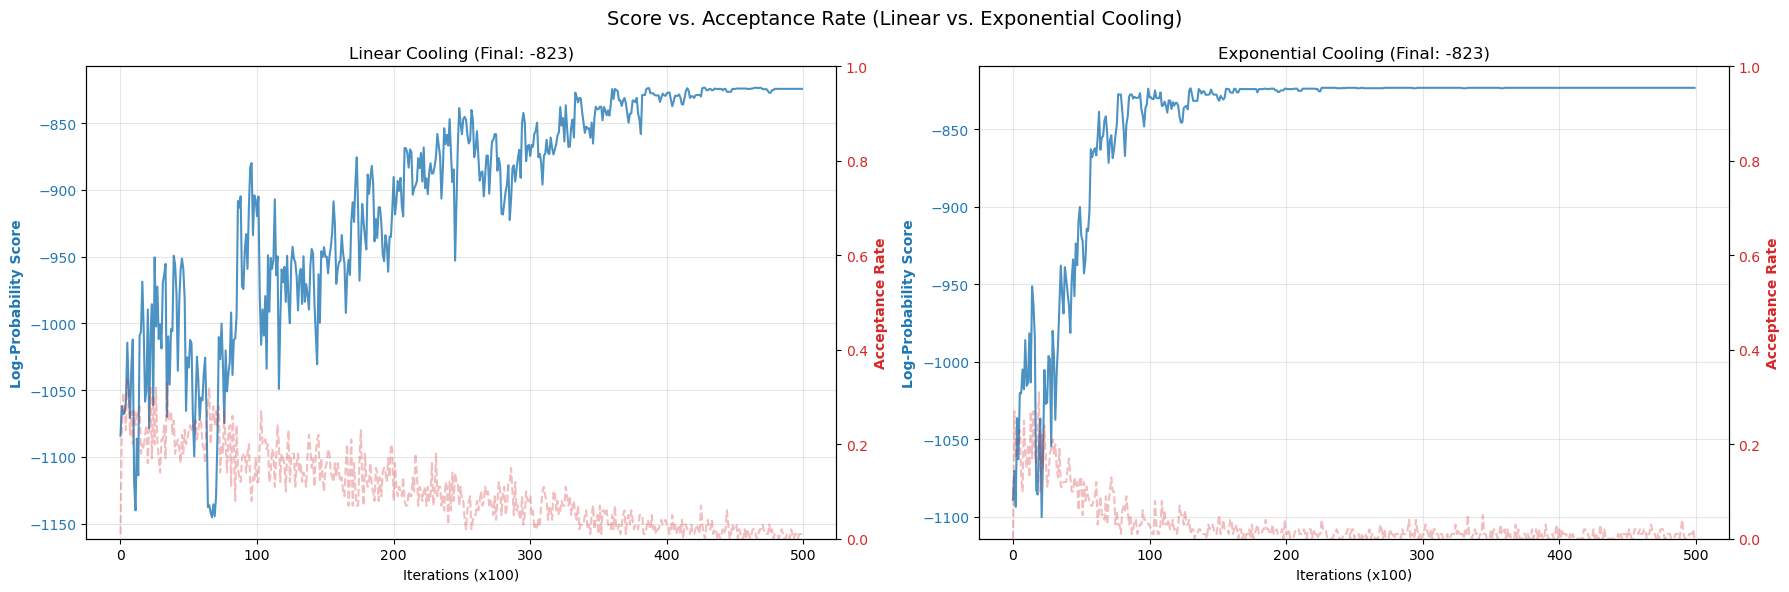

In [40]:
# Runs the comparison on Message 1 to demonstrate the difference.
print("Comparing Cooling Schedules on Message 1...\n")
compareCoolingSchedules(codedMessages[1])

### **Analysis of Results**
The graphs above illustrate the distinct behaviours of the two temperature schedules:

* **Linear Cooling (Left)**:
    * **Red Line (Rate)**: The acceptance rate decreases linearly and stays high (>5%) for the majority of the run. This indicates the system remains in a high-energy state, continuing to accept detrimental swaps (noise) late into the process.
    * **Blue Line (Score)**: Consequently, the score fluctuates wildly. The algorithm struggles to settle on a maximum because the high acceptance rate prevents it from "freezing" into a stable configuration until the very end.

* **Exponential Cooling (Right)**:
    * **Red Line (Rate)**: The acceptance rate plummets rapidly in the early phase.
    * **Blue Line (Score)**: As the acceptance rate hits near-zero, the score stabilizes almost instantly. The flat blue line indicates the system has successfully "frozen" into the ground state (the correct decryption) much earlier than in the linear model.

#### **Conclusion & Next Steps**
While both methods eventually located the global minimum, **exponential cooling** is computationally superior. It forces the system to stop exploring and start refining much earlier, securing the correct solution with significantly fewer wasted steps.

Crucially, the fact that the exponential graph flatlines well before the simulation ends confirms that 50,000 steps is excessive for this problem. This observation leads directly to **Section 9.2**, where we will determine the optimal stopping point to further reduce runtime.

## **9.2: Step Count Optimisation (Early Stopping)**

As observed in Section 9.1, the exponential cooling schedule often converges to the global minimum (the correct decryption) long before the pre-set limit of 50,000 steps is reached. The subsequent iterations (represented by the flat sections of the graph) consume computational resources without yielding any improvement in the solution.

To eliminate this inefficiency, we implement an **early stopping** mechanism.

Instead of running for a fixed number of iterations, the algorithm will track the number of consecutive steps passed since the last improvement in the score.
1.  **Patience Counter**: We initialise a counter at zero.
2.  **Reset**: Every time a new `bestScore` is found, the counter resets to zero.
3.  **Increment**: If the step does not yield a new global best, the counter increments.
4.  **Termination**: If the counter exceeds a defined **patience threshold** (e.g., $4000$ steps), we assume the system has settled into the ground state and terminate the loop.

This approach transforms the algorithm from a fixed-time process to a dynamic one, ensuring that simple ciphers are solved in seconds while complex ones are still afforded the time needed to converge.

In [41]:
# Function to demonstrate the efficiency of early stopping.
def demonstrateEarlyStopping(code, matrix=logMatrix, startingKey=None, maxSteps=50000, patience=7500, minSteps=10000):
    """
    Runs the Metropolis algorithm with an early stopping mechanism.

    Arguments:
        code (str): The encrypted message to solve.
        matrix (list): The log-probability matrix. Defaults to logMatrix.
        startingKey (dict): The initial best-guess key. Defaults to None.
        maxSteps (int): The maximum allowable iterations (safety limit).
        patience (int): The number of steps without improvement before stopping.
        minSteps (int): The minimum steps to run before enabling early stopping (warm-up).

    Returns:
        None: Displays a graph showing the stopping point and prints the final decryption.
    """

    # Generates a frequency-based starting key if needed.
    if startingKey is None:
        startingKey = generateFrequencyKey(code, mobyFreqs)

    # Initialises plotting.
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_title(f'Early Stopping Demonstration (Patience: {patience}, Warm-up: {minSteps})')

    # Converts code to indices.
    codeIndices = textToIndices(code)

    # Sets up the key map.
    currentKeyMap = [0] * len(alphabet)
    for c, p in startingKey.items():
        if c in charToIndex and p in charToIndex:
            currentKeyMap[charToIndex[c]] = charToIndex[p]

    # Initialises scores.
    decryptedIndices = [currentKeyMap[x] for x in codeIndices]
    currentScore = score(decryptedIndices, matrix)
    bestScore = currentScore
    
    # Initialises the best key map tracking.
    bestKeyMap = list(currentKeyMap)

    scoreHistory = []

    # Parameters for Exponential Cooling.
    tStart = 10
    tEnd = 0.01
    
    # Calculate alpha once outside the loop for optimization
    alpha = (tEnd / tStart) ** (1 / maxSteps)

    # Initialises the patience counter.
    stepsSinceImprovement = 0
    stoppedAt = 0

    for step in range(maxSteps):
        stoppedAt = step

        # Proposal.
        i, j = random.sample(range(len(alphabet)), 2)
        currentKeyMap[i], currentKeyMap[j] = currentKeyMap[j], currentKeyMap[i]

        # Scoring.
        decryptedIndices = [currentKeyMap[x] for x in codeIndices]
        newScore = score(decryptedIndices, matrix)
        diff = newScore - currentScore

        # Update Temperature using pre-calculated alpha
        tCurrent = tStart * (alpha ** step)

        # Acceptance (including conditional probability clause)
        if diff > 0 or math.exp(diff / tCurrent) > random.random():
            currentScore = newScore
            if currentScore > bestScore:
                bestScore = currentScore
                # Updates the best key found so far.
                bestKeyMap = list(currentKeyMap)
                stepsSinceImprovement = 0
            else:
                stepsSinceImprovement += 1
        else:
            currentKeyMap[i], currentKeyMap[j] = currentKeyMap[j], currentKeyMap[i]
            stepsSinceImprovement += 1

        scoreHistory.append(currentScore)

        # Early stopping check (Enforced only after minSteps).
        if step > minSteps and stepsSinceImprovement > patience:
            print(f'Stopping early at step {step} (No improvement for {patience} steps).')
            break

    # Reconstructs the final key and prints the message using the best key found.
    finalKey = {}
    for i, plainIndex in enumerate(bestKeyMap):
        finalKey[alphabet[i]] = alphabet[plainIndex]
        
    print(f'\nFinal Decryption Result:\n{applyCipher(code, finalKey)}\n')
    
    # Plots the history.
    ax.plot(scoreHistory, color="tab:green", label="Score")

    # Visualises the saving.
    if stoppedAt < maxSteps - 1:
        ax.axvline(x=stoppedAt, color='red', linestyle='--', label=f'Stopped ({stoppedAt})')
        ax.set_xlim(0, maxSteps)
        ax.fill_between([stoppedAt, maxSteps], min(scoreHistory), max(scoreHistory), color='gray', alpha=0.1, label="Computations Saved")

    ax.set_xlabel("Iterations")
    ax.set_ylabel("Log-Probability Score")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show();
    
print("Early stopping function successfully defined.")

Early stopping function successfully defined.


### **Results**
Now we'll run the early stopping algorithm on Message 1 to see if it is able to save any meaningful amount of computation power.

Running Early Stopping Test on Message 1...
Stopping early at step 18927 (No improvement for 7500 steps).

Final Decryption Result:
PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIZES CODE READAKILITY BITH ITS NOTAKLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OKWECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS BRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE PROWECTS



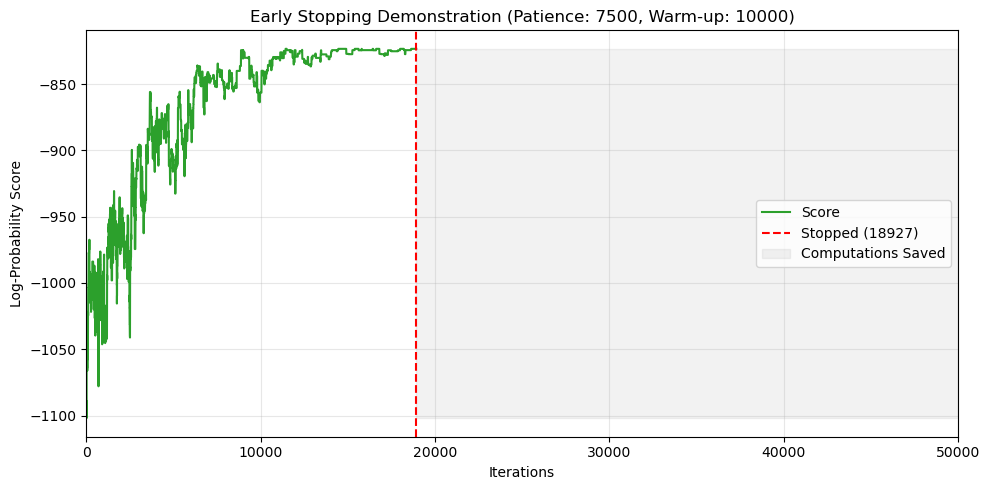

In [42]:
# Runs the demonstration on Message 1 with a Warm-up period.
print("Running Early Stopping Test on Message 1...")
demonstrateEarlyStopping(codedMessages[1])

### **Analysis of Results**
The demonstration confirms the utility of the *early stopping* mechanism combined with a **warm-up** period.
* **Computational Efficiency**: The algorithm tends to terminate between iteration $15,000$ and $25,000$, pruning more than half of its allocated steps with no significant loss in decryption accuracy.
* **Convergence Behaviour**: The graph shows high volatility during the initial *warm-up* phase, where the temperature is high. Once the algorithm enters the cooling phase, the score stabilises quickly. The flat green line preceding the cut-off indicates that the system had settled into a stable state.
* **Decryption Quality**. The final output is highly intelligible English. However, minor substitutions remain. A common error is `OKWECT` instead of `OBJECT`. This indicates that while the algorithm successfully located the global minimum for the Bigram model, the Bigram model itself is imperfect, validating our earlier implementation of **trigram** and **dictionary scoring** in Extention 7, which provides the nuance required to resolve these final few errors.

## **9.3: Sensitivity to Message Length (Quantifying the Limit)**

In Extension 7, we identified that statistical methods struggle with short ciphertexts due to the "rough energy landscape" (insufficient frequency data to form a smooth gradient).

This experiment aims to empirically verify that hypothesis and determine the **critical length**: the specific character count below which the Metropolis algorithm typically fails.

**Methodology:**
1.  **Controlled Slicing**: We take a long segment of English text (~1000 characters) and slice it into progressively smaller windows (e.g. 500, 300, 200, 150, 100, 50, 30, 15).
2.  **Randomised Encryption**: For each length, we encrypt the slice using a **new, random substitution key**, testing the solver's ability to find a solution from scratch, rather than being skewed by a lucky one.
3.  **Measurement**: We run the solver on each segment and calculate the **accuracy** (percentage of correctly recovered letters).

In [43]:
# Function to measure decryption accuracy.
def measureAccuracy(original, decrypted):
    """
    Compares two strings and returns the percentage of matching characters.

    Arguments:
        original (str): The true plaintext.
        decrypted (str): The solver's output.

    Returns:
        float: The accuracy percentage (0.0 to 100.0).
    """
    if len(original) != len(decrypted): return 0
    matches = sum(1 for a, b in zip(original, decrypted) if a == b)
    return (matches / len(original)) * 100

# Function to test solver performance across different text lengths.
def runLengthExperiment(fullText, matrix=logMatrix, steps=30000, trials=5):
    """
    Slices text into various lengths, encrypts with random keys, and tests solver accuracy.
    Averages results over multiple trials to reduce noise.

    Arguments:
        fullText (str): The long source text to slice.
        matrix (list): The log-probability matrix. Defaults to logMatrix.
        steps (int): Iterations per solve.
        trials (int): Number of times to test each length to get an average.

    Returns:
        None: Displays a graph of Accuracy vs Length.
    """

    # Defines test lengths focusing on the transition region.
    testLengths = [500, 300, 200, 150, 100, 50, 30, 15]
    avgAccuracies = []

    print(f"Running Length Sensitivity Experiment ({trials} trials per length)...")
    # Cleans the full text first to ensure valid comparisons.
    cleanText = clean(fullText)

    for L in testLengths:
        # Skips lengths longer than the available text.
        if L > len(cleanText): continue

        trialScores = []

        for t in range(trials):
            # Slices the text to the specific length L.
            plainSlice = cleanText[:L]

            # Generates a random encryption key for this specific test.
            # Prevents the solver from 'learning' a static key.
            alphaList = list(alphabet)
            shuffled = list(alphabet)
            random.shuffle(shuffled)
            encryptKey = {plaintext: cipher for plaintext, cipher in zip(alphaList, shuffled)}

            # Encrypts the slice.
            cipherSlice = applyCipher(plainSlice, encryptKey)

            # Solves the cipher (Quiet mode).
            # Generates a fresh frequency key for the starting point.
            freqKey = generateFrequencyKey(cipherSlice, mobyFreqs)
            solvedKey = metropolisSolve(cipherSlice, matrix, startingKey=freqKey, steps=steps, printInterval=0, printFinal=False)

            # Decrypts and measures accuracy.
            decryptedSlice = applyCipher(cipherSlice, solvedKey)
            acc = measureAccuracy(plainSlice, decryptedSlice)
            trialScores.append(acc)

        # Averages the scores for this length.
        avgScore = sum(trialScores) / trials
        avgAccuracies.append(avgScore)

        print(f'Length: {L:4d} chars | Avg Accuracy: {avgScore:6.2f}%')

    # Visualises the results.
    plt.figure(figsize=(10, 6))
    plt.plot(testLengths, avgAccuracies, marker='o', linestyle='-', color='purple', linewidth=2, label="Accuracy")

    plt.title(f'Solver Reliability vs. Message Length (Avg of {trials} runs)')
    plt.xlabel("Message Length (Characters)")
    plt.ylabel("Average Accuracy (%)")
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis() # Largest lengths on left.
    plt.legend()
    plt.show()

print("Length vs accuracy measurement functions successfully defined.")

Length vs accuracy measurement functions successfully defined.


### **Results**

We execute the `runLengthExperiment` on a sample text to empirically measure the drop in solver reliability as message length decreases. The resulting graph plots the **average decryption accuracy** against the **message length** (in characters), averaging the results over five randomized trials to smooth out variance from individual key difficulty.

Running Length Sensitivity Experiment (5 trials per length)...
Length:  500 chars | Avg Accuracy: 100.00%
Length:  300 chars | Avg Accuracy:  89.27%
Length:  200 chars | Avg Accuracy:  43.50%
Length:  150 chars | Avg Accuracy:  42.67%
Length:  100 chars | Avg Accuracy:  28.20%
Length:   50 chars | Avg Accuracy:  30.80%
Length:   30 chars | Avg Accuracy:  23.33%
Length:   15 chars | Avg Accuracy:  18.67%


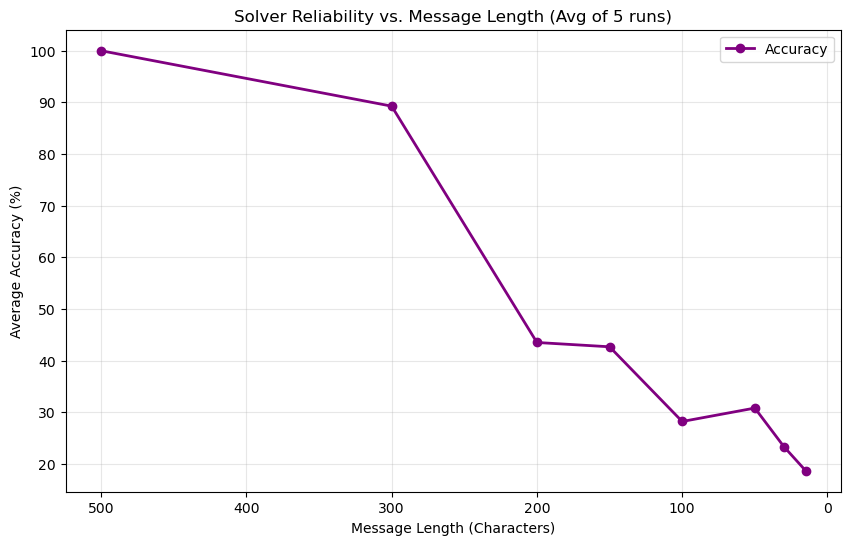

In [44]:
# Runs the experiment on a sample of text from Moby Dick.
runLengthExperiment(moby[5000:6000], trials=5)

### **Analysis of Results**

The graph visually quantifies the **law of large numbers**.

* **Failure Zone (<200 chars):** Below this length, the **signal to noise ratio** is too low, and the accuracy drops rapidly. The solver lacks the necessary statistical data (bigrams) to distinguish the true key from random, incorrect permutations.
* **Optimal Region (>300 chars):** The highest accuracy often occurs in ands above the 300-character range. This represents a "sweet spot" where the text is long enough to provide a strong statistical signal.
  
#### **Conclusion**
This empirically validates the limitations of pure bigram Metropolis, validating the need for the more powerful tools (like the trigram and dictionary hybrid solver defined in Extension 7) for shorter messages.

# **Extension 10**: Adaptation to Other Ciphers

The Metropolis algorithm is a universal optimisation framework. While we have applied it exclusively to **monoalphabetic substitution** ciphers so far, it is equally effective for any cryptographic system where the "correctness" of a decryption can be statistically quantified.

The goal of this extension is to demonstrate this versatility by adapting the solver to break two fundamentally different classes of cipher:

* **10.1 - Columnar Transposition**: A permutation-based cipher where the position of letters changes, not their identity.
* **10.2 - Vigenère Cipher**: A polyalphabetic substitution cipher where letter identity changes based on a rotating key.

*Note: To isolate the efficacy of the mutation logic for these specific ciphers, we will utilise the standard **bigram log-probability matrix** (Core 5).*

### **Transposition Message Database**
To rigorously evaluate the solver, we define a dictionary of **three test cases** with varying lengths. The algorithm must be robust enough to solve short messages (low signal-to-noise) and long messages (high computational load).

## **10.1: Columnar Transposition Cipher**

### **Methodology: Encryption**
In a **Columnar Transposition** cipher, the text is written row-wise into a grid, the width of which is determined by the length of the keyword. The columns are then shuffled based on the alphabetical order of the letters in the keyword.

To decrypt this, we must reconstruct the original column order. Unlike substitution ciphers, **letter frequencies remain identical** to the plaintext; only their *positions* change. Therefore, simple frequency analysis (Core 3) is useless here.

In [45]:
# Repository for Extension 10 specific ciphertexts.
transpositionMessages = {
    1: 'THEY WENT THE GHOST AND SCROOGE ACROSS THE HALL TO A DOOR AT THE BACK OF THE HOUSE',
    2: 'PRESENTLY HER EYE WANDERED TO THE OTHER AND SHE WAS SURPRISED TO RECOGNISE IN HIM A CERTAIN MR HYDE WHO HAD ONCE VISITED HER MASTER AND FOR WHOM SHE HAD CONCEIVED A DISLIKE HE HAD IN HIS HAND A HEAVY CANE WITH WHICH HE WAS TRIFLING BUT HE ANSWERED NEVER A WORD AND SEEMED TO LISTEN WITH AN ILLCONTAINED IMPATIENCE',
    3: 'IT WAS ON A DREARY NIGHT OF NOVEMBER THAT I BEHELD THE ACCOMPLISHMENT OF MY TOILS WITH AN ANXIETY THAT ALMOST AMOUNTED TO AGONY I COLLECTED THE INSTRUMENTS OF LIFE AROUND ME THAT I MIGHT INFUSE A SPARK OF BEING INTO THE LIFELESS THING THAT LAY AT MY FEET IT WAS ALREADY ONE IN THE MORNING THE RAIN PATTERED DISMALLY AGAINST THE PANES AND MY CANDLE WAS NEARLY BURNT OUT WHEN BY THE GLIMMER OF THE HALFEXTINGUISHED LIGHT I SAW THE DULL YELLOW EYE OF THE CREATURE OPEN IT BREATHED HARD AND A CONVULSIVE MOTION AGITATED ITS LIMBS HOW CAN I DESCRIBE MY EMOTIONS AT THIS CATASTROPHE OR HOW DELINEATE THE WRETCH WHOM WITH SUCH INFINITE PAINS AND CARE I HAD ENDEAVOURED TO FORM HIS LIMBS WERE IN PROPORTION AND I HAD SELECTED HIS FEATURES AS BEAUTIFUL BEAUTIFUL GREAT GOD HIS YELLOW SKIN SCARCELY COVERED THE WORK OF MUSCLES AND ARTERIES BENEATH HIS HAIR WAS OF A LUSTROUS BLACK AND FLOWING HIS TEETH OF A PEARLY WHITENESS'
}
print("Transposition message database successfully defined.")

Transposition message database successfully defined.


In [46]:
def columnarEncrypt(text, key):
    """
    Encrypts a message using a Columnar Transposition cipher.
    
    Arguments:
        text (str): The plaintext message.
        key (str): The keyword determining column order.
        
    Returns:
        str: The encrypted ciphertext.
    """

    # Assigns a number to each letter of the key based on its relative position in the alphabet.
    # This is in order to determine how the characters are transposed.
    sortedKey = sorted(key)
    keyNumbers = []
    for c in key:
        keyNumbers.append(sortedKey.index(c))
    
    messageList = list(text)
    messageList = [c for c in messageList]

    n = len(key)
    m = len(messageList)

    # Converts the text to indices for scoring.
    indices = textToIndices(text)
    currentScore = score(indices, logMatrix)

    # The text is written row-wise into a grid with 'n' columns.
    transpositionMatrix = []
    for k in range(m//n):
        row = messageList[k*n:(k+1)*n]
        transpositionMatrix.append(row)
        
    finalRow = messageList[n*(m//n):m]
    remainder = n - len(finalRow)
    finalRow.extend('*'*remainder)
    transpositionMatrix.append(finalRow)
    
    transpositionMatrix = np.array(transpositionMatrix, dtype=object)
    column = 0

    # The encoded message is then reassembled column-wise.
    encodedMessage = []
    while column < len(key):
        for i in range(len(transpositionMatrix)):
            encodedRow = []
            j = keyNumbers.index(column)
            encodedRow.append(str(transpositionMatrix[i, j]))
            encodedMessage.extend(encodedRow)
        column += 1
        encodedMessage = [c for c in encodedMessage]

    return ''.join(encodedMessage)

print("Columnar encryption function successfully defined.")

Columnar encryption function successfully defined.


### **Methodology: The Metropolis Solver**
To break this cipher, we adapt the Metropolis parameters using a **NumPy-based grid approach**:

1.  **State Space**: The state is defined by the **order of the columns** in the grid.
2.  **Mutation**: Instead of swapping keys in a dictionary, the algorithm selects **two random columns** in the grid and swaps their positions.
3.  **Scoring**: The text is read out row-by-row from the current grid state. The **Bigram Score** (Core 5) of this resulting string determines the energy of the state.

By minimising the "energy" (maximising the bigram score), the algorithm shuffles the columns until they align to form coherent English words.

In [47]:
def metropolisTransposition(text, minKeyLength, maxKeyLength, steps=10000, tStart=10, tEnd=0.01, printInterval=5000):
    """
    Breaks a Columnar Transposition cipher using Metropolis optimization.
    Iterates through a range of key lengths to find the best global solution.
    
    Arguments:
        text (str): The ciphertext to decrypt.
        minKeyLength (int): The minimum assumed length of the keyword.
        maxKeyLength (int): The maximum assumed length of the keyword.
        steps (int): Number of iterations per key length.
        tStart (float): Starting temperature.
        tEnd (float): Ending temperature.
        printInterval (int): Frequency of status updates.
        
    Returns:
        str: The best decrypted text found across all key lengths.
    """
    
    # Variables to track the best result across all key lengths.
    overallBestText = ""
    overallBestScore = -float('inf')
    overallBestKey = []
    
    # Loops through the requested range of key lengths.
    for k in range(minKeyLength, maxKeyLength + 1):
        
        keyLength = k
        
        print(f"\nTesting key length {keyLength}...")
        
        m = len(text)
        
        # Calculates alpha for geometric cooling.
        alpha = (tEnd / tStart) ** (1 / steps)

        # The text is written into a grid with k columns (once transposed).
        l = m//keyLength
        textMatrix = []
        for i in range(keyLength):
            textMatrix.append(list(text[i*l:(i+1)*l]))
        
        textMatrix = np.array(textMatrix, dtype=object)
        textMatrix = textMatrix.T
        
        # Initialises key permutation [0, 1, 2, ...].
        currentKeyPerm = list(range(keyLength))
        
        # Sets up initial conditions for metropolis algorithm.
        textMatrixCurrent = copy.deepcopy(textMatrix)
        textStringCurrent = ''.join(char for row in textMatrixCurrent for char in row if char != '*')
        
        indicesCurrent = textToIndices(textStringCurrent)
        sCurrent = score(indicesCurrent, logMatrix)
        
        textStringBest = textStringCurrent
        sBest = sCurrent
        bestKeyPerm = list(currentKeyPerm)
        
        for step in range(steps+1):
            # Updates Temperature.
            tCurrent = tStart * (alpha ** step)
            
            # Does not modify original list or sublists.
            textMatrixNew = copy.deepcopy(textMatrixCurrent)
            newKeyPerm = list(currentKeyPerm)
            
            # Selects two random columns.
            i, j = random.sample(range(keyLength), 2)
                
            # Swaps the values in these columns for each row.
            textMatrixNew[:, [i, j]] = textMatrixNew[:, [j, i]]
            
            # Swaps the key indices to track the permutation.
            newKeyPerm[i], newKeyPerm[j] = newKeyPerm[j], newKeyPerm[i]
            
            # Filters out '*' from the message in order to be able to calculate the score
            textStringNew = ''.join(char for row in textMatrixNew for char in row if char != '*')
            indicesNew = textToIndices(textStringNew)
            sNew = score(indicesNew, logMatrix)
            
            # Metropolis Acceptance Logic
            diff = sNew - sCurrent
            if diff > 0 or math.exp(diff / tCurrent) > random.random():
                # If the new score is greater or accepted by probability, change the message
                textMatrixCurrent = textMatrixNew
                textStringCurrent = textStringNew
                indicesCurrent = indicesNew
                sCurrent = sNew
                currentKeyPerm = newKeyPerm
                
                # Tracks the global highest score for the current key length.
                if sCurrent > sBest:
                    textStringBest = textStringNew
                    sBest = sCurrent
                    bestKeyPerm = list(currentKeyPerm)
                    
            # Prints the progress at defined intervals.
            if printInterval > 0 and (step % printInterval == 0):
                print(f'Iteration {step}: T={tCurrent:.2f}, Score={sCurrent:.2f}, Key={currentKeyPerm}, Text: {textStringCurrent[:60]}...')
    

        # Compares the best result from this key length against the overall best found so far.
        if sBest > overallBestScore:
            overallBestScore = sBest
            overallBestText = textStringBest
            overallBestKey = bestKeyPerm
            
    print(f"\nFinal Best Key Found: {overallBestKey}")
    # Returns the text with the overall highest score.
    return overallBestText

print("Columnar Metropolis solver successfully defined.")

Columnar Metropolis solver successfully defined.


### **Results**
We test the solver on transposed message 1. The output is produced correctly most of the time.

In [48]:
print(f'Original text:\n{transpositionMessages[1]}\n')

encodedText = columnarEncrypt(transpositionMessages[1], 'DUCKS')
print(f'Encoded text:\n{encodedText}\n')

print("Starting Decryption...")
# Updated variable names and added printInterval
decodedText = metropolisTransposition(encodedText, steps=10000, minKeyLength=2, maxKeyLength=10, printInterval=5000)

print(f'\nDecoded text:\n{decodedText}')

Original text:
THEY WENT THE GHOST AND SCROOGE ACROSS THE HALL TO A DOOR AT THE BACK OF THE HOUSE

Encoded text:
ENESDOAS    HC H*TWTHACEOHL O BOESYT T OC HTDAEKTO*  G SGRTAOOT  HU*HEHONR SELARTAF E

Starting Decryption...

Testing key length 2...
Iteration 0: T=10.00, Score=-305.85, Key=[1, 0], Text: HETNDEASEDKOTAOS     G  HSCG RHTATOWOTTH A CHEUOHHLE HOO NBR...
Iteration 5000: T=0.32, Score=-305.85, Key=[1, 0], Text: HETNDEASEDKOTAOS     G  HSCG RHTATOWOTTH A CHEUOHHLE HOO NBR...
Iteration 10000: T=0.01, Score=-305.85, Key=[1, 0], Text: HETNDEASEDKOTAOS     G  HSCG RHTATOWOTTH A CHEUOHHLE HOO NBR...

Testing key length 3...
Iteration 0: T=10.00, Score=-315.81, Key=[0, 2, 1], Text: EGONR ETBSAODOEOOSATYS T    HT U  OHHCCE  HHHOTNDTRAW ETSKHE...
Iteration 5000: T=0.32, Score=-278.97, Key=[2, 1, 0], Text: GOER NTBEAOSOEDOSOTYA TS   HT U  O HCHE CHH OTHNDRAT EWSKTET...
Iteration 10000: T=0.01, Score=-278.97, Key=[2, 1, 0], Text: GOER NTBEAOSOEDOSOTYA TS   HT U  O HCHE CHH OTHNDRAT EWSKT

## **10.2: Vigenère Cipher**

### **Methodology: Encryption**
The **Vigenère cipher** is a polyalphabetic substitution system. The encryption key consists of a word (e.g. `DUCKS`) repeated to match the length of the plaintext. Each letter of the text is shifted by an amount determined by the corresponding letter of the key.

In [49]:
def vigenereEncrypt(text, key):
    """
    Encrypts a message using a Vigenère cipher.
    
    Arguments:
        text (str): The plaintext message.
        key (str): The keyword for polyalphabetic shifting.
        
    Returns:
        str: The encrypted ciphertext.
    """

    textListOriginal = [c for c in text]
    m = len(textListOriginal)
    k = len(key)
    N = len(alphabet) 

    indicesList = [alphabet.index(c) for c in textListOriginal if c in alphabet]

    # Repeats the key to match text length.
    shiftList = []
    for i in range(m):
        i %= k
        shift = alphabet.index(key[i])
        shiftList.append(shift)

    # Shifts each character according to its respective key.
    textListShifted = []
    for i in range(len(indicesList)):
        oldIndex = indicesList[i]
        
        newIndex = (oldIndex + shiftList[i]) % N

        # Creates the encrypted text.
        textListShifted.append(alphabet[newIndex])
        
    encodedText = ''.join(textListShifted)
    
    return encodedText

print("Vigenère encryption function successfully defined.")

Vigenère encryption function successfully defined.


### **Methodology: The Metropolis Solver**
For Vigenère, we do not swap letters in the text. Instead, we use Metropolis to **evolve the cipher key itself**.

1.  **State Space**: A list of integers representing the shift values of the key (e.g., `[3, 20, 2, 10, 18]`).
2.  **Mutation**: We randomly select **two positions** in the key and change them to a random integer between **0 and 26**.
3.  **Scoring**: The ciphertext is decrypted using the candidate key, and the resulting plaintext is scored using the Bigram Matrix.

In [50]:
def metropolisVigenere(text, steps, minKeyLength, maxKeyLength, tStart=100, tEnd=0.1, printInterval=5000):
    """
    Breaks a Vigenère cipher using Metropolis optimisation on the Key itself.
    Iterates through a range of key lengths to find the best global solution.

    Arguments:
        text (str): The ciphertext.
        steps (int): Number of iterations per key length.
        minKeyLength (int): The minimum assumed length of the keyword.
        maxKeyLength (int): The maximum assumed length of the keyword.
        tStart (float): Starting temperature.
        tEnd (float): Ending temperature.
        printInterval (int): Frequency of status updates.

    Returns:
        str: The best decrypted text found across all key lengths.
    """

    # Variables to track the best result across all key lengths
    overallBestText = ""
    overallBestScore = -float('inf')
    overallBestKey = []
    
    # Defines alphabet size.
    N = len(alphabet)

    # Loops through the requested range of key lengths.
    for k in range(minKeyLength, maxKeyLength + 1):

        # Assigns current 'k' to 'keyLength'.
        keyLength = k

        print(f"\nTesting key length {keyLength}...")

        m = len(text)
        charFreqs = list(getFrequencies(moby).values())

        # Calculates alpha for geometric cooling.
        alpha = (tEnd / tStart) ** (1 / steps)

        # Initial random key guess based on frequency weights.
        keyGuessCurrent = [alphabet.index(c) for c in random.choices(alphabet, weights=charFreqs, k=keyLength)]

        # Scores the initial guess.
        textListCurrent = list(text)
        textListShifted = []
        for i in range(m):
            oldIndex = alphabet.index(textListCurrent[i])
            # Decryption: (Cipher - Key) % N
            newIndex = (oldIndex - keyGuessCurrent[i % keyLength]) % N
            textListShifted.append(alphabet[newIndex])

        # Creates the guess string and scores it.
        textGuessCurrent = "".join(textListShifted)
        indicesCurrent = textToIndices(textGuessCurrent)
        sCurrent = score(indicesCurrent, logMatrix)

        # Creates a basline to score future iterations against.
        textGuessBest = textGuessCurrent
        sBest = sCurrent
        keyGuessBest = keyGuessCurrent

        tCurrent = tStart

        # Metropolis Loop.
        for step in range(steps + 1):
            # Updates Temperature.
            tCurrent *= alpha

            # Mutates Key.
            keyGuessNew = copy.deepcopy(keyGuessCurrent)

            # Change 2 random positions in the key to a random value (0 to 26)
            # Using 2 mutations prevents getting stuck in local minima for Vigenère
            indicesToChange = random.sample(range(keyLength), 2)
            for index in indicesToChange:
                keyGuessNew[index] = random.randint(0, N - 1)

            # Decrypts with new mutated key.
            textListShifted = []
            for i in range(m):
                oldIndex = alphabet.index(text[i])
                newIndex = (oldIndex - keyGuessNew[i % keyLength]) % N
                textListShifted.append(alphabet[newIndex])

            # Creates the guess string and scores it.
            textGuessNew = "".join(textListShifted)
            indicesNew = textToIndices(textGuessNew)
            sNew = score(indicesNew, logMatrix)

            # Metropolis Acceptance Logic
            diff = sNew - sCurrent
            if diff > 0 or math.exp(diff / tCurrent) > random.random():
                # Accepts new state
                textGuessCurrent = textGuessNew
                sCurrent = sNew
                keyGuessCurrent = keyGuessNew

                # Updates best key/guess found for this key length.
                if sCurrent > sBest:
                    textGuessBest = textGuessNew
                    sBest = sCurrent
                    keyGuessBest = keyGuessNew

            # Consistent progress printing.
            if printInterval > 0 and (step % printInterval == 0):
                print(f'Iteration {step}: T={tCurrent:.2f}, Score={sCurrent:.2f}, Key={keyGuessCurrent}, Text: {textGuessBest[:60]}...')

        # Compares the best result from this key length against the overall best found so far,
        if sBest > overallBestScore:
            overallBestScore = sBest
            overallBestText = textGuessBest
            overallBestKey = keyGuessBest

    # Converts numeric key back to letters for display.
    finalKeyString = "".join([alphabet[i] for i in overallBestKey])

    print(f"\nFinal Best Key Found: {overallBestKey} ('{finalKeyString}')")

    # Returns the text with the overall highest score.
    return overallBestText

print("Vigenère Metropolis solver successfully defined.")

Vigenère Metropolis solver successfully defined.


### **Results**
We'll apply the solver to transposed message 2.

In [51]:
print(f'Original text:\n{transpositionMessages[2]}\n')

vigenereEncoded = vigenereEncrypt(transpositionMessages[2], 'BIRDS')
print(f'Encoded text (Key: BIRDS):\n{vigenereEncoded}\n')

print("Starting Decryption...")
vigenereDecoded = metropolisVigenere(vigenereEncoded, steps=25000, minKeyLength=2, maxKeyLength=10, printInterval=12500)

print(f'\nDecoded text:\n{vigenereDecoded}')

Original text:
PRESENTLY HER EYE WANDERED TO THE OTHER AND SHE WAS SURPRISED TO RECOGNISE IN HIM A CERTAIN MR HYDE WHO HAD ONCE VISITED HER MASTER AND FOR WHOM SHE HAD CONCEIVED A DISLIKE HE HAD IN HIS HAND A HEAVY CANE WITH WHICH HE WAS TRIFLING BUT HE ANSWERED NEVER A WORD AND SEEMED TO LISTEN WITH AN ILLCONTAINED IMPATIENCE

Encoded text (Key: BIRDS):
R WWXPBCBSJNIDX NR TPMWVXFIKSSVQWDGVQWVSCWVDKJNR TUIJYJR  WXFIKSSTNUSZPRJISKWRLAOISDVG KEAPIDVSJGVISYQFD CMRSFENRZAURKIWBQWVSOJJXXTISRWBOFVSYQFQSUQWD CMRGGPLWMNGMRESFRJPAMNRLXBQSHSKWRLAUIZEFFISD GJMBSEJEISYRKLSYQ G BQWDOCARXJKOCMFIITYLBQWDTPANIJGMRRXXNIDTBEFVWBJEHSUNWQXFIKSSNRJXXPINMLJISRSKUCGGPBSMFGMRMERJKMXPLW

Starting Decryption...

Testing key length 2...
Iteration 0: T=99.97, Score=-1611.02, Key=[19, 4], Text: ZWDSELJZJORJQ EWVNHPXIDREBQG OCMD ORYSCOKSC SFVNHPBERURNHWDT...
Iteration 12500: T=3.16, Score=-1478.86, Key=[9, 18], Text: IINEOYTLTAAW MOIE RBGVNDOO TJAMZNMYDHEMAUEMMBSE RBLRAGA RINF...
Iteration 25000: T=0.10, Score=-147

### **Example: Vigenère Decryption (Message 3)**

In this final experiment, we apply the Vigenère cipher to **Message 3** (the longest text in our repository) using a two different keywords, `ALGORITHM` and `CIPHER`, confirming the Metropolis algorithm functions correctly with different keys, not just the `'BIRDS'` key used in Example 2.

In [52]:
print(f'Original text:\n{transpositionMessages[3]}\n')

vigenereEncoded = vigenereEncrypt(transpositionMessages[3], 'ALGORITHM')
print(f'Encoded text:\n{vigenereEncoded}\n')

print("Starting Decryption...")
vigenereDecoded = metropolisVigenere(vigenereEncoded, steps=10000, minKeyLength=2, maxKeyLength=10, printInterval=5000)

print(f'\nDecoded text:\n{vigenereDecoded}')

Original text:
IT WAS ON A DREARY NIGHT OF NOVEMBER THAT I BEHELD THE ACCOMPLISHMENT OF MY TOILS WITH AN ANXIETY THAT ALMOST AMOUNTED TO AGONY I COLLECTED THE INSTRUMENTS OF LIFE AROUND ME THAT I MIGHT INFUSE A SPARK OF BEING INTO THE LIFELESS THING THAT LAY AT MY FEET IT WAS ALREADY ONE IN THE MORNING THE RAIN PATTERED DISMALLY AGAINST THE PANES AND MY CANDLE WAS NEARLY BURNT OUT WHEN BY THE GLIMMER OF THE HALFEXTINGUISHED LIGHT I SAW THE DULL YELLOW EYE OF THE CREATURE OPEN IT BREATHED HARD AND A CONVULSIVE MOTION AGITATED ITS LIMBS HOW CAN I DESCRIBE MY EMOTIONS AT THIS CATASTROPHE OR HOW DELINEATE THE WRETCH WHOM WITH SUCH INFINITE PAINS AND CARE I HAD ENDEAVOURED TO FORM HIS LIMBS WERE IN PROPORTION AND I HAD SELECTED HIS FEATURES AS BEAUTIFUL BEAUTIFUL GREAT GOD HIS YELLOW SKIN SCARCELY COVERED THE WORK OF MUSCLES AND ARTERIES BENEATH HIS HAIR WAS OF A LUSTROUS BLACK AND FLOWING HIS TEETH OF A PEARLY WHITENESS

Encoded text:
JEGKSATW AMGSINUZKAZPVZBTWSAZVJWVVMDAEOPKIBHOFTL VIMPRA

In [53]:
print(f'Original text:\n{transpositionMessages[3]}\n')

vigenereEncoded = vigenereEncrypt(transpositionMessages[3], 'CIPHER')
print(f'Encoded text:\n{vigenereEncoded}\n')

print("Starting Decryption...")
vigenereDecoded = metropolisVigenere(vigenereEncoded, steps=10000, minKeyLength=2, maxKeyLength=10, printInterval=5000)

print(f'\nDecoded text:\n{vigenereDecoded}')

Original text:
IT WAS ON A DREARY NIGHT OF NOVEMBER THAT I BEHELD THE ACCOMPLISHMENT OF MY TOILS WITH AN ANXIETY THAT ALMOST AMOUNTED TO AGONY I COLLECTED THE INSTRUMENTS OF LIFE AROUND ME THAT I MIGHT INFUSE A SPARK OF BEING INTO THE LIFELESS THING THAT LAY AT MY FEET IT WAS ALREADY ONE IN THE MORNING THE RAIN PATTERED DISMALLY AGAINST THE PANES AND MY CANDLE WAS NEARLY BURNT OUT WHEN BY THE GLIMMER OF THE HALFEXTINGUISHED LIGHT I SAW THE DULL YELLOW EYE OF THE CREATURE OPEN IT BREATHED HARD AND A CONVULSIVE MOTION AGITATED ITS LIMBS HOW CAN I DESCRIBE MY EMOTIONS AT THIS CATASTROPHE OR HOW DELINEATE THE WRETCH WHOM WITH SUCH INFINITE PAINS AND CARE I HAD ENDEAVOURED TO FORM HIS LIMBS WERE IN PROPORTION AND I HAD SELECTED HIS FEATURES AS BEAUTIFUL BEAUTIFUL GREAT GOD HIS YELLOW SKIN SCARCELY COVERED THE WORK OF MUSCLES AND ARTERIES BENEATH HIS HAIR WAS OF A LUSTROUS BLACK AND FLOWING HIS TEETH OF A PEARLY WHITENESS

Encoded text:
LBPDFJCXCHFRG UIWPCWYOMKCXVHSFYNBJJICBXIYRLIRMMWOMPAMWC

### **Conclusion**

The Metropolis algorithm has proven adaptable for the examples given: the columnar transposition cipher and the Vigenère cipher. In both cases, we successfully adapted the key step-by-step, undoing the encryption until the result resembled a piece of English text according to our bigram scoring model.

However, this method does **not** work for the **One-Time Pad (OTP)**.
* **Reason 1:** For an OTP, the key is composed of a truly random stream of characters. Therefore, letter frequency analysis (and by extension, our scoring function) cannot be used to determine the most likely key, as *any* plaintext can be generated from the ciphertext given the "right" random key.
* **Reason 2:** The key is the same length as the text itself. This means each character is masked individually, removing all inter-character dependencies (bigrams/trigrams) that our algorithm relies upon.

Mathematically, a One-Time Pad returns a ciphertext containing zero information about the original text, making it unbreakable by this (or any) statistical method.

## **Full List of Deciphered Codes**
We were able to decrypt all provided messages in the project booklet aside from 10 and 12. Below is the full list of deciphered messages.

In [54]:
for i in [1,2,3,4,5,6,7,8,9,11]:
    print(f'Deciphered message {i}:\n{punctuatedDecryptions[i]}\n')

Deciphered message 1:
Python is an interpreted high level and general-purpose programming language. Python's design philosophy emphasises code readability with its notable use of significant indentation. Its language constructs and object-oriented approach aim to help programmers write clear and logical code for small- and large-scale projects.

Deciphered message 2:
Sherlock Holmes preserved his calm professional manner until our visitor had left, although it was easy for me, who knew him so well, to see that he was profoundly excited the moment that Hilton Cubitt's broad back had disappeared through the door. My comrade rushed to the table, laid out all the slips of paper containing dancing men in front of him, and threw himself into an intricate and elaborate calculation for two hours. I watched him as he covered sheet after sheet of paper with figures and letters, so completely absorbed in his task that he had evidently forgotten my presence. Sometimes he was making progress and wh

# **Project Conclusion**

In this project, we explored the intersection of **statistical physics** and **cryptography**, treating decryption not as a linguistic puzzle, but as an energy minimisation problem.

* **The Physics Approach:** By implementing the **Metropolis algorithm** and **simulated annealing**, we successfully automated the search for the global minimum (the correct key) within a massive solution space ($27!$). We visualised this process as a cooling system, allowing the key to escape local maxima (gibberish) and "freeze" into a stable ground state (English).
* **Refinement & Limits:** We overcame the "rough energy landscapes" of difficult texts by upgrading to **Trigram models** and **Hybrid Dictionary scoring** (Extension 7). However, our **Length Sensitivity Analysis** (Extension 9) empirically confirmed a hard physical limit: below a critical character count, the statistical signal is lost to noise, making purely probabilistic decryption impossible (as seen with messages 10 & 12).
* **Versatility:** Finally, **Extension 10** demonstrated the universality of this method. By simply redefining the "state" and "mutation" logic, we adapted the exact same thermodynamic principles to successfully break **Columnar Transposition** and **Vigenère** ciphers, proving the algorithm is not limited to simple mono-alphabetic substitution.

We noticed that Message 12 contains exactly one instance of every letter (A-Z). This results in a perfectly uniform frequency distribution, effectively neutralizing most statistical attacks by eliminating the frequency gradients required for the algorithm to descend toward a solution.

Ultimately, this project highlights that while cryptographic security relies on the complexity of the solution space, random sampling algorithms derived from thermodynamics provide an extremely efficient tool for navigating that space.

### **Bibliography**

**Literature & Data Sources**

$[1]$ Melville, H., 2001. *Moby Dick; Or, The Whale*. Project Gutenberg. Available at: [https://www.gutenberg.org/ebooks/2701](https://www.gutenberg.org/ebooks/2701).

$[2]$ Verne, J., 2004. *Vingt mille lieues sous les mers*. Project Gutenberg. Available at: [https://www.gutenberg.org/ebooks/5097](https://www.gutenberg.org/ebooks/5097).

$[3]$ Bjørnson, B., 2004. *Gesammelte Werke*. Project Gutenberg. Available at: [https://www.gutenberg.org/ebooks/12921](https://www.gutenberg.org/ebooks/12921).

$[4]$ dwyl, hbenbel, & hermitdave. *Open Source Dictionaries*. GitHub. Accessed via: [english-words](https://github.com/dwyl/english-words), [French-Dictionary](https://github.com/hbenbel/French-Dictionary), [wordlists](https://raw.githubusercontent.com/hermitdave/FrequencyWords/master/content/2018/de/de_50k.txt).

**Theory & Algorithms**

$[5]$ Metropolis, N., Rosenbluth, A.W., Rosenbluth, M.N., Teller, A.H. and Teller, E., 1953. Equation of state calculations by fast computing machines. *The Journal of Chemical Physics*, 21(6), pp.1087-1092.

$[6]$ Shah, A. V. & Shah, P., 2022. Model of Cryptography System by using Vigenere Cipher and Polybius Cipher. *International Journal of Innovative Research in Engineering & Multidisciplinary Physical Sciences*, 10(6), pp. 4–8.